In [1]:
import warnings
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from data_consistency_checker import DataConsistencyChecker

In [2]:
# This notebook provides some examples of patterns and discovered in datasets
# on OpenML. For most datasets, at least one pattern of some interest can usually
# be found. In some cases, we include two or more here, but we mostly stick to
# one to keep the size of the notebook down, because not all patterns found
# are interesting, some are similar to other patterns, and the number of patterns
# found that are interesting is quite large. 

# We limit each test to one example as well. 

In [3]:
def demo_test(filename, test_id_arr, issue_id_arr=None, features_arr=None):
    
    # Load the data. OpenML marks version 1 of a few of these datasets as inactive, and warns about
    # it. We keep version 1, so the examples stay the same.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Version 1 of dataset", category=UserWarning)
        data = fetch_openml(filename, version=1)
    df = pd.DataFrame(data.data, columns=data.feature_names)
    display(df.head())
    
    # Run DataConsistencyChecker with default parameters, other than verbose=0
    # to skip printing the test IDs as the tests exectute. 
    dc = DataConsistencyChecker(verbose=0)  
    dc.init_data(df)
    _ = dc.check_data_quality(execute_list=test_id_arr)
    
    # If specific issues are specified, list only these.
    if issue_id_arr is not None:
        dc.display_detailed_results(issue_id_list=issue_id_arr)
    elif features_arr is not None:
        dc.display_detailed_results(col_name_list=features_arr)
    else:
        dc.display_detailed_results(test_id_list=test_id_arr)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


Error LARGER is not a valid test

Data consistency check complete.
Analysed 4,177 rows, 8 columns
Executed 2 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 4 patterns with exceptions
2 tests (100.00% of tests) flagged at least one exception each.
Flagged 20 row(s) with at least one exception.
Flagged 6 column(s) with at least one exception.
....................................................................................................


### SIMILAR_WRT_RATIO

### Columns(s): "Length" AND "Diameter"

**Issue&nbsp;ID**:&nbsp;0

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.0479%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,Length,Diameter,RATIO
9,0.550000,0.440000,1.250000
15,0.500000,0.400000,1.250000
24,0.615000,0.480000,1.281250
26,0.580000,0.450000,1.288889
28,0.605000,0.475000,1.273684
30,0.580000,0.470000,1.234043
143,0.560000,0.455000,1.230769
151,0.605000,0.500000,1.210000
153,0.605000,0.485000,1.247423
156,0.575000,0.460000,1.250000


**Flagged&nbsp;values**:

,Length,Diameter,RATIO
898,0.280000,0.120000,2.333333
1210,0.185000,0.375000,0.493333


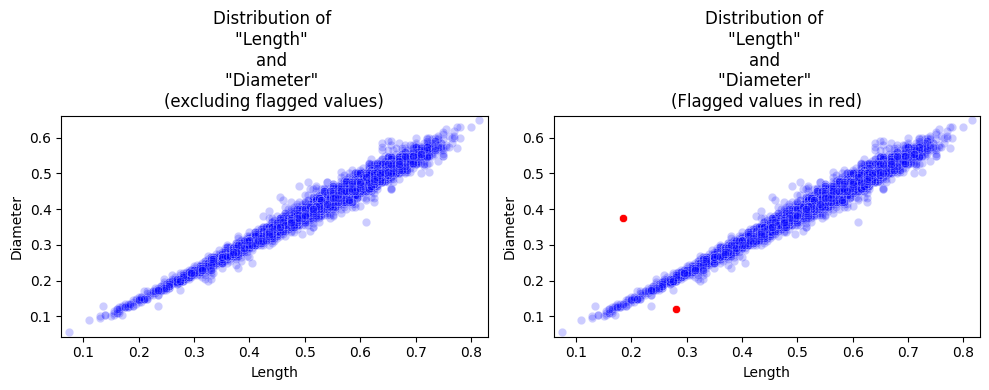

....................................................................................................


### LARGER_THAN_SUM

### Columns(s): "Shucked_weight" AND "Viscera_weight" AND "Whole_weight"

**Issue&nbsp;ID**:&nbsp;1

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;9&nbsp;(0.2155%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,Shucked_weight,Viscera_weight,Whole_weight,SUM
53,0.210500,0.105500,0.477500,0.316000
179,0.385000,0.216500,0.970000,0.601500
398,0.256000,0.139000,0.676500,0.395000
679,0.093000,0.026000,0.222500,0.119000
818,0.065500,0.048000,0.180000,0.113500
836,0.266000,0.093500,0.580500,0.359500
907,0.077500,0.030500,0.196000,0.108000
1004,0.526500,0.264500,1.134500,0.791000
1075,0.132000,0.072000,0.324500,0.204000
1854,0.181000,0.097500,0.494000,0.278500


**Flagged&nbsp;values**:

,Shucked_weight,Viscera_weight,Whole_weight,SUM
822,0.086000,0.058500,0.137500,0.144500
1216,0.435000,0.015000,0.105500,0.450000
1264,0.358000,0.077500,0.372000,0.435500
2114,0.005000,0.006500,0.010500,0.011500
2127,0.106000,0.071000,0.127000,0.177000
2171,0.015500,0.015000,0.029500,0.030500
2627,0.495000,0.019000,0.105500,0.514000
2641,0.202500,0.087500,0.131500,0.290000
3086,0.304500,0.046000,0.204000,0.350500


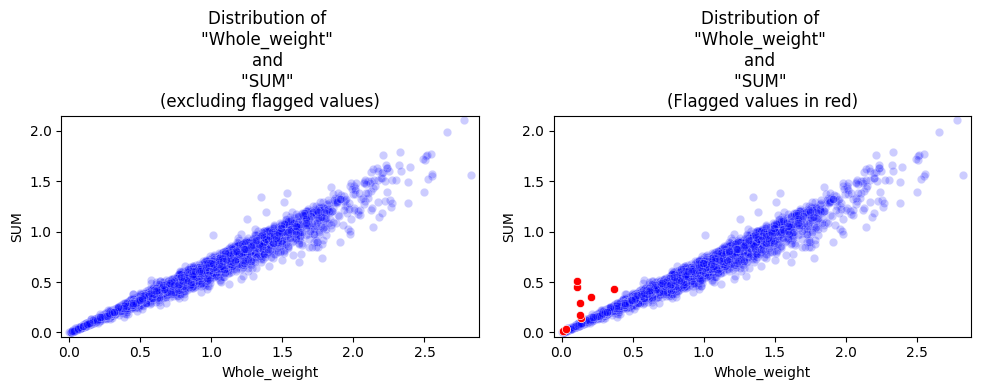

### Columns(s): "Shucked_weight" AND "Shell_weight" AND "Whole_weight"

**Issue&nbsp;ID**:&nbsp;2

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;The&nbsp;values&nbsp;in&nbsp;"Whole_weight"&nbsp;are&nbsp;consistently&nbsp;larger&nbsp;than&nbsp;the&nbsp;sum&nbsp;of&nbsp;"Shucked_weight",&nbsp;&nbsp;and<br>"Shell_weight",&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;16&nbsp;(0.3831%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,Shucked_weight,Shell_weight,Whole_weight,SUM
53,0.210500,0.150000,0.477500,0.360500
179,0.385000,0.350000,0.970000,0.735000
398,0.256000,0.260000,0.676500,0.516000
679,0.093000,0.080000,0.222500,0.173000
818,0.065500,0.054000,0.180000,0.119500
836,0.266000,0.169000,0.580500,0.435000
907,0.077500,0.044500,0.196000,0.122000
1004,0.526500,0.295000,1.134500,0.821500
1075,0.132000,0.106000,0.324500,0.238000
1854,0.181000,0.191000,0.494000,0.372000


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,Shucked_weight,Shell_weight,Whole_weight,SUM
193,0.092000,0.150000,0.220000,0.242000
236,0.001000,0.001500,0.002000,0.002500
822,0.086000,0.060500,0.137500,0.146500
1216,0.435000,0.040000,0.105500,0.475000
1219,0.056500,0.090000,0.139000,0.146500
1264,0.358000,0.110000,0.372000,0.468000
1302,0.359500,0.225000,0.576500,0.584500
1430,0.019000,0.036000,0.051500,0.055000
2127,0.106000,0.085000,0.127000,0.191000
2627,0.495000,0.031500,0.105500,0.526500


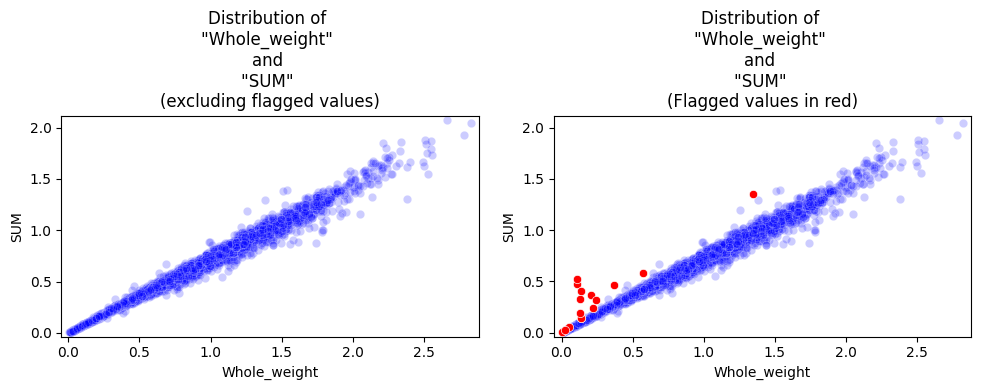

In [4]:
demo_test("abalone", test_id_arr=['LARGER', 'SIMILAR_WRT_RATIO', 'LARGER_THAN_SUM'], issue_id_arr=[9, 0, 1, 2, 8])

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country
0,2,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States
2,2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States
3,3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba



Data consistency check complete.
Analysed 48,842 rows, 14 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 4 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 616 row(s) with at least one exception.
Flagged 6 column(s) with at least one exception.



### Columns(s): "workclass" AND "race" AND "capitalgain"

**Issue&nbsp;ID**:&nbsp;0

Unusual&nbsp;values&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;173&nbsp;(0.3542%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,workclass,race,capitalgain
0,State-gov,White,1.000000
1,Self-emp-not-inc,White,0.000000
2,Private,White,0.000000
8,Private,White,4.000000
9,Private,White,2.000000
59,Private,White,2.000000
60,Private,White,1.000000
84,Private,White,4.000000
105,Self-emp-inc,White,3.000000
300,Private,White,3.000000


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,workclass,race,capitalgain
206,Private,Black,2.000000
230,Private,Black,2.000000
738,Private,Black,1.000000
978,Private,Black,1.000000
1396,Private,Black,2.000000
1427,Private,Black,1.000000
2593,Private,Black,3.000000
2906,Private,Black,1.000000
3384,Private,Black,4.000000
3477,Private,Black,2.000000


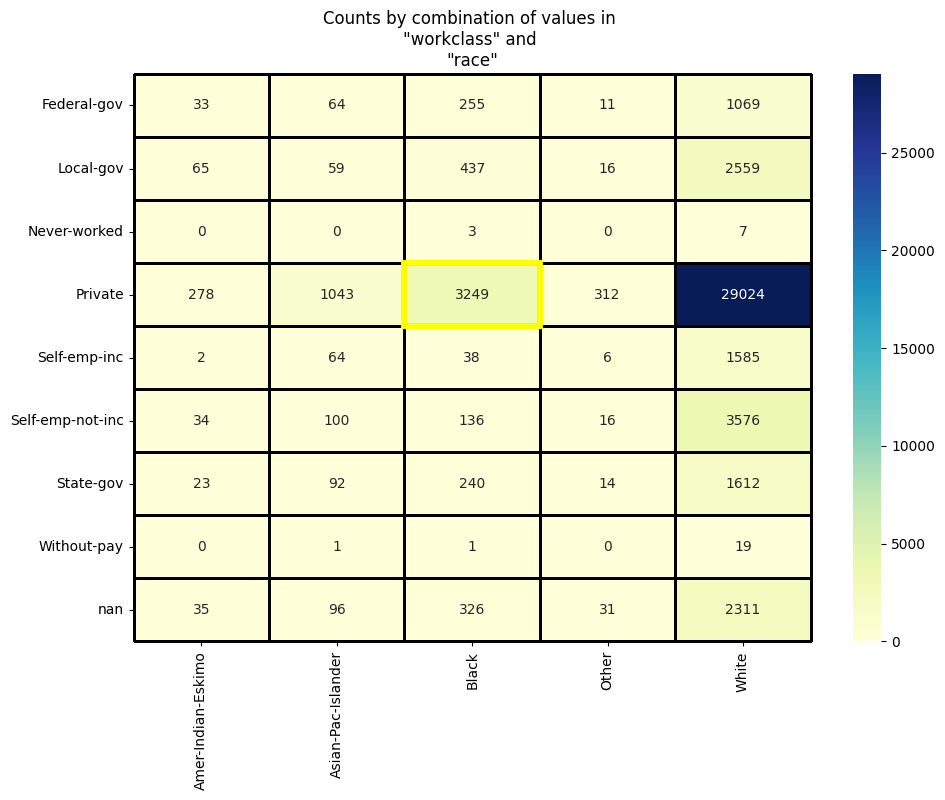

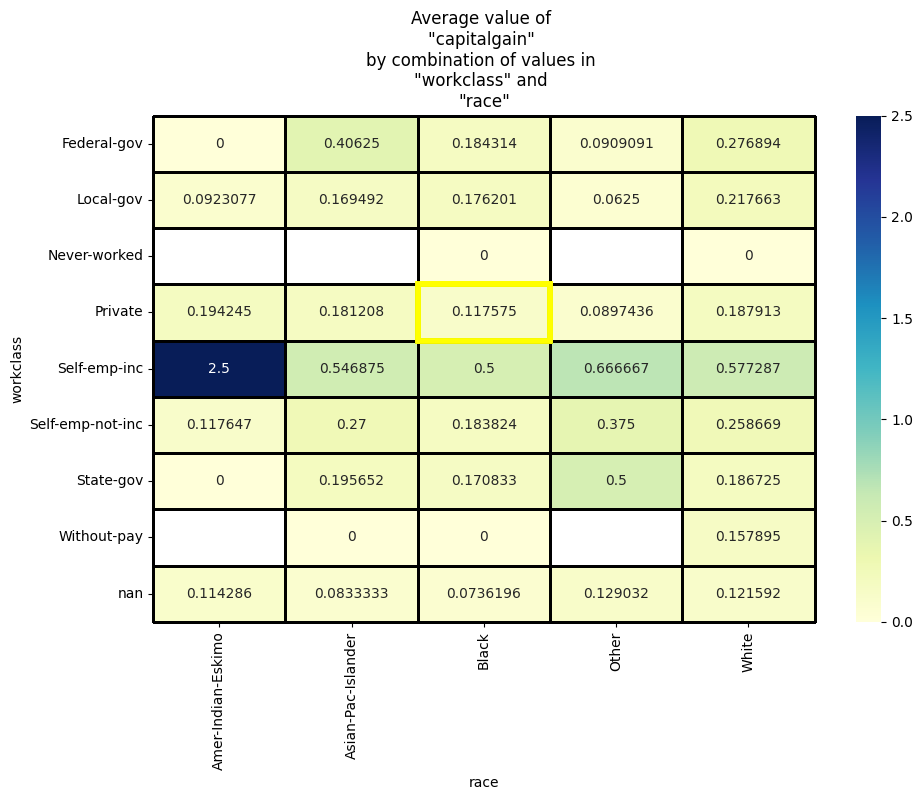

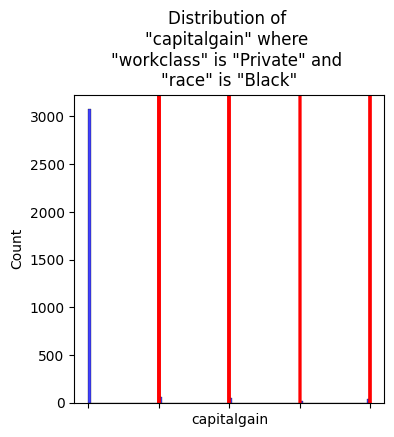

In [5]:
demo_test("adult", test_id_arr=['LARGE_GIVEN_PAIR'], issue_id_arr=[0])

,family,product-type,steel,carbon,hardness,temper_rolling,condition,formability,strength,non-ageing,...,jurofm,s,p,shape,thick,width,len,oil,bore,packing
0,NaN,C,A,8,0,NaN,S,NaN,0,NaN,...,NaN,NaN,NaN,COIL,0.700,610.0,0,NaN,0,NaN
1,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,NaN,COIL,3.200,610.0,0,NaN,0,NaN
2,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,NaN,SHEET,0.700,1300.0,762,NaN,0,NaN
3,NaN,C,A,0,60,T,NaN,NaN,0,NaN,...,NaN,NaN,NaN,COIL,2.801,385.1,0,NaN,0,NaN
4,NaN,C,A,0,60,T,NaN,NaN,0,NaN,...,NaN,NaN,NaN,SHEET,0.801,255.0,269,NaN,0,NaN



Data consistency check complete.
Analysed 898 rows, 31 columns
Executed 2 tests.

Patterns without Exceptions:
Found 2 patterns without exceptions
1 tests (50.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 3 patterns with exceptions
2 tests (100.00% of tests) flagged at least one exception each.
Flagged 5 row(s) with at least one exception.
Flagged 7 column(s) with at least one exception.
....................................................................................................


### NON_ZERO

### Columns(s): width

**Issue&nbsp;ID**:&nbsp;0

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.2227%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,width
0,610.000000
2,1300.000000
8,1320.000000
13,609.900000
14,1220.000000
22,50.000000
28,900.000000
38,20.000000
53,150.000000
78,1250.000000


**Flagged&nbsp;values**:

,width
606,0.000000
845,0.000000


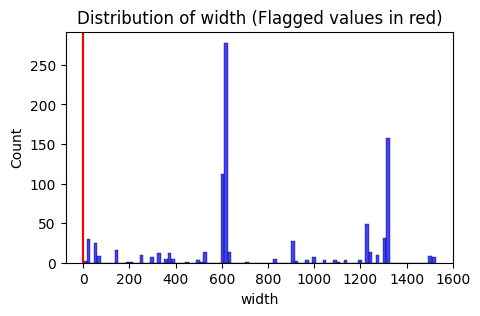

....................................................................................................


### DECISION_TREE_CLASSIFIER

### Columns(s): "carbon" AND "hardness" AND "temper_rolling"

**Issue&nbsp;ID**:&nbsp;1

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.2227%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,carbon,hardness,temper_rolling,PREDICTION
0,8,0,nan,nan
1,0,0,nan,nan
2,0,0,nan,nan
3,0,60,T,T
4,0,60,T,T
5,0,45,nan,nan
6,0,0,nan,nan
17,0,80,T,T
19,0,70,T,T
22,0,85,T,T


**Flagged&nbsp;values**:

,carbon,hardness,temper_rolling,PREDICTION
110,0,0,T,nan
585,0,0,T,nan


In [6]:
demo_test("anneal", test_id_arr=['NON_ZERO', 'DECISION_TREE_CLASSIFIER'], issue_id_arr=[0, 1])

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source
0,34,1,0,0,0,0,0,0,0,0,...,27,1,28,1,72,1,10,0,0,1
1,15,1,0,0,0,0,0,0,0,0,...,22,1,3,0,146,0,234,0,0,4
2,40,2,0,0,0,0,0,0,0,0,...,69,1,10,1,48,1,22,0,0,4
3,67,1,1,0,0,0,0,0,0,0,...,20,1,83,0,146,0,234,0,0,4
4,67,1,0,0,0,0,0,0,0,0,...,12,1,201,1,44,1,199,0,0,3



Data consistency check complete.
Analysed 3,772 rows, 27 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 2 row(s) with at least one exception.
Flagged 2 column(s) with at least one exception.



### Columns(s): "T4U_measured" AND "FTI_measured"

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.0530%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,T4U_measured,FTI_measured
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
27,0,0
39,0,0
54,0,0


**Flagged&nbsp;values**:

,T4U_measured,FTI_measured
765,0,1
1515,0,1


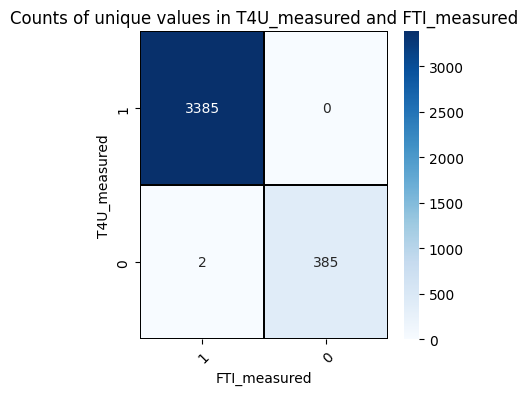

In [7]:
demo_test("allbp", test_id_arr=['SAME_VALUES'])

,Number_seasons,Games_played,At_bats,Runs,Hits,Doubles,Triples,Home_runs,RBIs,Walks,Strikeouts,Batting_average,On_base_pct,Slugging_pct,Fielding_ave,Position
0,23,3298,12364,2174,3771,624,98,755,2297,1402,1383.0,0.305,0.377,0.555,0.980,Outfield
1,13,1165,4019,378,1022,163,19,57,366,208,499.0,0.254,0.294,0.347,0.985,Second_base
2,13,1424,5557,844,1588,249,48,9,394,453,223.0,0.286,0.343,0.353,0.974,Second_base
3,14,1281,4019,591,1082,188,49,37,303,414,447.0,0.269,0.340,0.368,0.955,Third_base
4,17,1959,6606,823,1832,295,35,336,1122,594,1059.0,0.277,0.339,0.485,0.994,First_base



Data consistency check complete.
Analysed 1,340 rows, 16 columns
Executed 1 tests.

Patterns without Exceptions:
Found 2 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): "Games_played" AND "Runs" AND "Hits" AND "RBIs" AND "Walks" AND "Strikeouts" AND "Slugging_pct" AND "At_bats"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"At_bats"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.010&nbsp;+&nbsp;&nbsp;0.28&nbsp;*&nbsp;"Games_played"&nbsp;+&nbsp;&nbsp;0.07&nbsp;*&nbsp;"Runs"&nbsp;+&nbsp;&nbsp;0.79&nbsp;*&nbsp;"Hits"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"RBIs"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"Walks"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"Strikeouts"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"Slugging_pct"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,Games_played,Runs,Hits,RBIs,Walks,Strikeouts,Slugging_pct,At_bats,PREDICTION
1,1165,378,1022,366,208,499.000000,0.347000,4019,3886.887651
13,1236,390,846,296,250,636.000000,0.343000,3330,3420.515513
141,1286,718,1203,418,672,575.000000,0.379000,4553,4451.265397
213,918,384,731,278,232,384.000000,0.359000,2877,2820.282071
279,1458,388,1312,647,386,326.000000,0.430000,4255,4197.039083
360,644,282,506,167,240,264.000000,0.326000,1963,1711.753140
442,1475,735,1415,805,731,356.000000,0.466000,4992,4864.188094
683,1264,522,1099,479,299,421.000000,0.400000,4101,4101.915942
1190,1597,585,1163,370,456,593.000000,0.332000,4677,4748.526693
1206,863,301,559,133,219,384.000000,0.293000,2322,2432.526545


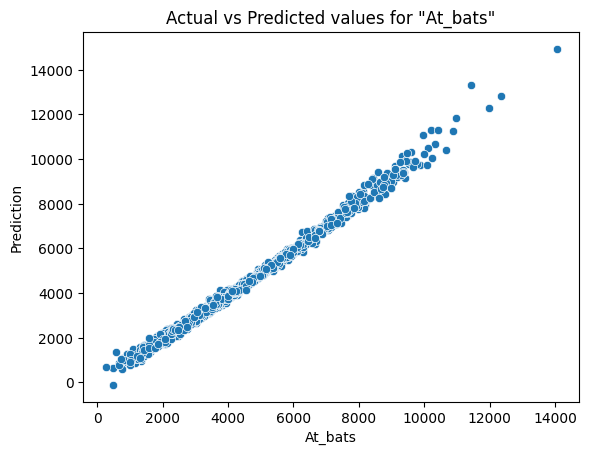

### Columns(s): "Games_played" AND "At_bats" AND "Runs" AND "Doubles" AND "Triples" AND "Home_runs" AND "RBIs" AND "Batting_average" AND "On_base_pct" AND "Hits"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"Hits"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.000&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"Games_played"&nbsp;+&nbsp;&nbsp;0.70&nbsp;*&nbsp;"At_bats"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"Runs"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"Doubles"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"Triples"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"Home_runs"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"RBIs"&nbsp;+&nbsp;&nbsp;0.15&nbsp;*&nbsp;"Batting_average"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"On_base_pct"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,Games_played,At_bats,Runs,Doubles,Triples,Home_runs,RBIs,Batting_average,On_base_pct,Hits,PREDICTION
29,1324,4369,386,135,26,60,457,0.252000,0.310000,1103,1077.599605
100,1540,5562,692,221,40,106,556,0.254000,0.315000,1415,1432.493198
102,976,3068,363,143,24,56,355,0.272000,0.325000,833,830.870915
120,1446,4481,682,218,71,26,530,0.279000,0.385000,1252,1292.151776
124,1252,4169,457,95,32,2,348,0.255000,0.347000,1064,1044.955605
338,883,2672,259,116,13,69,391,0.262000,0.315000,699,676.583359
371,743,2852,376,129,34,21,294,0.239000,0.253000,682,660.086624
416,1092,3285,438,107,22,61,340,0.239000,0.352000,786,755.734504
448,918,3000,486,155,67,35,449,0.294000,0.373000,881,945.084727
694,1212,3802,453,193,26,71,442,0.256000,0.329000,972,969.318123


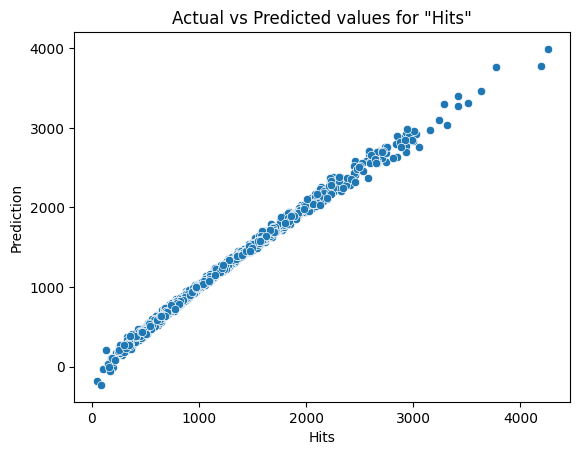

In [8]:
demo_test("baseball", test_id_arr=['LINEAR_REGRESSION'])

In [9]:
demo_test("bank-marketing", test_id_arr=['COLUMN_ORDERED_ASC'])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown



Data consistency check complete.
Analysed 45,211 rows, 16 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.
No patterns or exceptions to display.


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,0.243144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,0.106480,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,0.352308,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,0.208989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,0.125177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Data consistency check complete.
Analysed 3,751 rows, 1776 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 5 row(s) with at least one exception.
Flagged 4 column(s) with at least one exception.



### Columns(s): "D1073" AND "D210" AND "D129" AND "D183"

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;5&nbsp;(0.1333%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,D1073,D210,D129,D183,PREDICTION
0,0.000000,0.927678,0.000000,0.976740,0.976457
1,0.000000,0.722861,0.052600,0.951294,0.950162
35,1.000000,0.921839,0.105263,0.976014,0.976457
1179,0.000000,0.768641,0.157895,0.956982,0.931250
1946,1.000000,0.954159,0.210526,0.983462,0.976457
2046,1.000000,0.869861,0.157895,0.969557,0.976457
3457,1.000000,0.833547,0.105263,0.965045,0.960087
3466,0.000000,0.757475,0.157895,0.920275,0.931250
3482,0.000000,0.774521,0.157895,0.942778,0.931250
3723,0.000000,0.859863,0.105263,0.968315,0.976457


**Flagged&nbsp;values**:

,D1073,D210,D129,D183,PREDICTION
432,1.000000,0.729264,0.526316,0.763945,0.960087
763,0.000000,0.186705,0.789474,0.382419,0.931250
807,1.000000,0.360995,0.210526,0.841749,0.960087
1407,1.000000,0.000000,1.000000,0.000000,0.960087
2262,1.000000,0.233848,0.526316,0.652369,0.960087


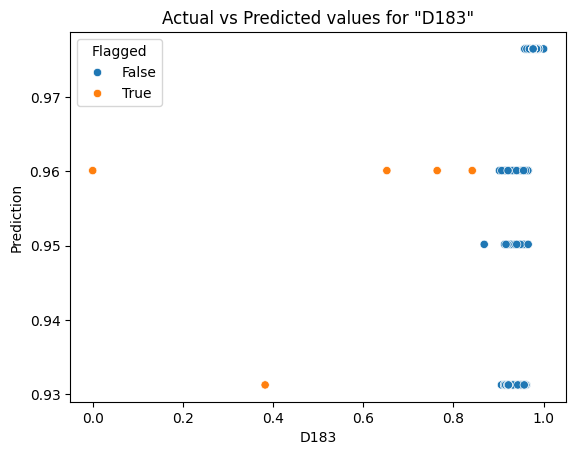

In [10]:
demo_test("bioresponse", test_id_arr=['DECISION_TREE_REGRESSOR'])

,V1,V2,V3,V4
0,2,50,12500,98
1,0,13,3250,28
2,1,16,4000,35
3,2,20,5000,45
4,1,24,6000,77



Data consistency check complete.
Analysed 748 rows, 4 columns
Executed 3 tests.

Patterns without Exceptions:
Found 2 patterns without exceptions
2 tests (66.67% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'CONSTANT_RATIO',&nbsp;'EVEN_MULTIPLE',&nbsp;'LINEAR_REGRESSION'

....................................................................................................


### CONSTANT_RATIO

### Columns(s): "V2" AND "V3"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;ratio&nbsp;of&nbsp;"V2"&nbsp;and&nbsp;"V3"&nbsp;is&nbsp;consistently&nbsp;close&nbsp;to&nbsp;0.004

**Examples**:

,V2,V3,DIVISION RESULTS
5,4,1000,0.004000
6,7,1750,0.004000
8,9,2250,0.004000
11,3,750,0.004000
14,6,1500,0.004000
15,5,1250,0.004000
21,11,2750,0.004000
29,8,2000,0.004000
47,2,500,0.004000
153,1,250,0.004000


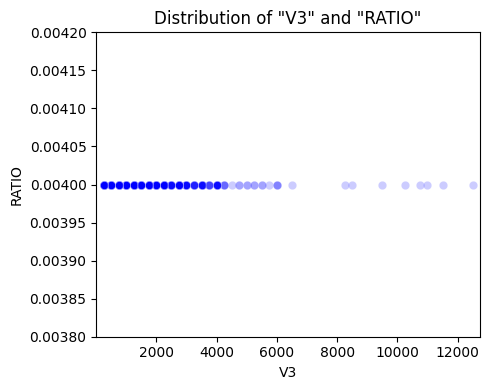

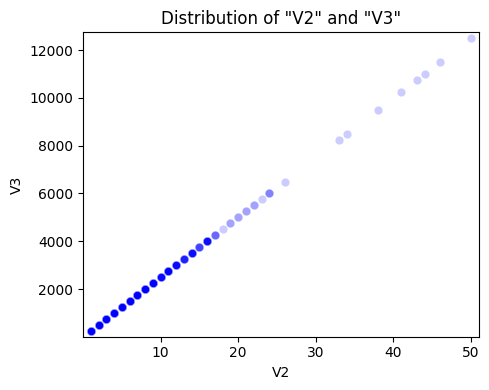

....................................................................................................


### EVEN_MULTIPLE

### Columns(s): "V3" AND "V2"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V3"&nbsp;is&nbsp;consistently&nbsp;an&nbsp;even&nbsp;integer&nbsp;multiple&nbsp;of&nbsp;"V2"

**Examples**:

,V3,V2,DIVISION RESULTS
0,12500,50,250.000000
1,3250,13,250.000000
2,4000,16,250.000000
3,5000,20,250.000000
4,6000,24,250.000000
5,1000,4,250.000000
6,1750,7,250.000000
7,3000,12,250.000000
8,2250,9,250.000000
9,11500,46,250.000000


In [11]:
demo_test("blood-transfusion-service-center", test_id_arr=['CONSTANT_RATIO', 'EVEN_MULTIPLE', 'LINEAR_REGRESSION'])

In [12]:
demo_test("car-evaluation", test_id_arr=['GROUPED_STRINGS', 'PREV_VALUES_DT'])

,buying_price_vhigh,buying_price_high,buying_price_med,buying_price_low,maintenance_price_vhigh,maintenance_price_high,maintenance_price_med,maintenance_price_low,doors_2,doors_3,...,doors_5more,persons_2,persons_4,persons_more,luggage_boot_size_small,luggage_boot_size_med,luggage_boot_size_big,safety_low,safety_med,safety_high
0,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,1,0,0,0,1,0
2,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,1,0,0,0,0,1
3,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,1,0,1,0,0
4,1,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0



Data consistency check complete.
Analysed 1,728 rows, 21 columns
Executed 2 tests.

Patterns without Exceptions:
Found 6 patterns without exceptions
1 tests (50.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'GROUPED_STRINGS',&nbsp;'PREV_VALUES_DT'

....................................................................................................


### PREV_VALUES_DT

...

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:

The values in safety_high can consistently be predicted from the previous values in the column with a decision tree using the following rules: 

|--- The value 3 rows previously was not '0'
|   |--- value: 1
|--- The value 3 rows previously was '0'
|   |--- value: 0




**Examples&nbsp;(showing&nbsp;a&nbsp;consecutive&nbsp;set&nbsp;of&nbsp;rows)**:

,safety_high,PREDICTION
718,0,0
719,1,1
720,0,0
721,0,0
722,1,1
723,0,0
724,0,0
725,1,1
726,0,0
727,0,0


In [13]:
demo_test("car", test_id_arr=['PREV_VALUES_DT'])

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med



Data consistency check complete.
Analysed 1,728 rows, 6 columns
Executed 1 tests.

Patterns without Exceptions:
Found 3 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): persons

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:

...

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:

The values in safety can consistently be predicted from the previous values in the column with a decision tree using the following rules: 

|--- The value 1 row previously was not 'low'
|   |--- The value 1 row previously was not 'med'
|   |   |--- value: low
|   |--- The value 1 row previously was 'med'
|   |   |--- value: high
|--- The value 1 row previously was 'low'
|   |--- value: med




**Examples&nbsp;(showing&nbsp;a&nbsp;consecutive&nbsp;set&nbsp;of&nbsp;rows)**:

,safety,PREDICTION
810,low,low
811,med,med
812,high,high
813,low,low
814,med,med
815,high,high
816,low,low
817,med,med
818,high,high
819,low,low


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35
0,23,240,357,120,120,0,0,0,73,0.5,...,0,0,0,0,0,0,0,0,1,0
1,45,5,632,132,132,4,0,4,17,2.1,...,0,0,0,0,0,1,0,0,0,0
2,45,177,779,133,133,2,0,5,16,2.1,...,0,0,0,0,0,1,0,0,0,0
3,45,411,1192,134,134,2,0,6,16,2.4,...,0,0,0,0,0,1,0,0,0,0
4,45,533,1147,132,132,4,0,5,16,2.4,...,0,1,0,0,0,0,0,0,0,0



Data consistency check complete.
Analysed 2,126 rows, 35 columns
Executed 3 tests.

Patterns without Exceptions:
Found 7 patterns without exceptions
2 tests (66.67% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'BINARY_IMPLIES',&nbsp;'SAME_VALUES',&nbsp;'SIMILAR_WRT_DIFF'

....................................................................................................


### BINARY_IMPLIES

### Columns(s): "V26" AND "V27"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V26"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"V27"&nbsp;value:&nbsp;0

**Examples**:

,V26,V27
0,0,0
1,0,0
4,0,1
13,0,1
42,1,0
57,1,0
661,0,0
1133,0,0
1293,0,1
1330,0,0


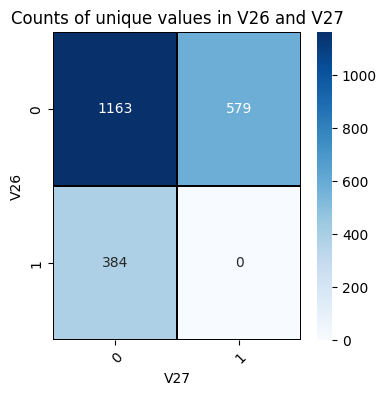

### Columns(s): "V26" AND "V31"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V26"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"V31"&nbsp;value:&nbsp;0

**Examples**:

,V26,V31
0,0,0
1,0,1
2,0,1
4,0,0
42,1,0
57,1,0
389,0,0
959,0,0
2013,0,0
2047,0,0


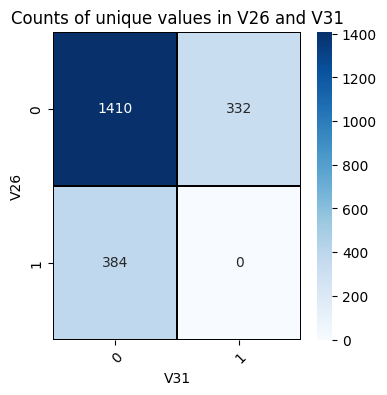

### Columns(s): "V26" AND "V32"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V26"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"V32"&nbsp;value:&nbsp;0

**Examples**:

,V26,V32
0,0,0
1,0,0
17,0,1
28,0,1
42,1,0
56,0,0
57,1,0
182,0,1
687,0,0
1110,0,0


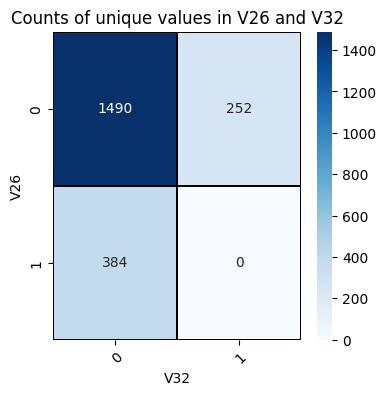

### Columns(s): "V27" AND "V31"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V27"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"V31"&nbsp;value:&nbsp;0

**Examples**:

,V27,V31
0,0,0
1,0,1
2,0,1
4,1,0
5,0,0
13,1,0
77,1,0
1066,0,0
1901,1,0
1932,0,0


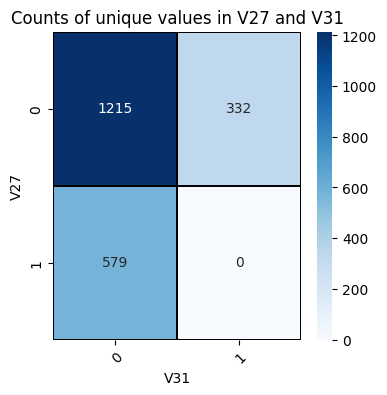

### Columns(s): "V27" AND "V32"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V27"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"V32"&nbsp;value:&nbsp;0

**Examples**:

,V27,V32
0,0,0
1,0,0
4,1,0
13,1,0
17,0,1
28,0,1
156,0,0
1221,0,0
1696,0,0
1883,1,0


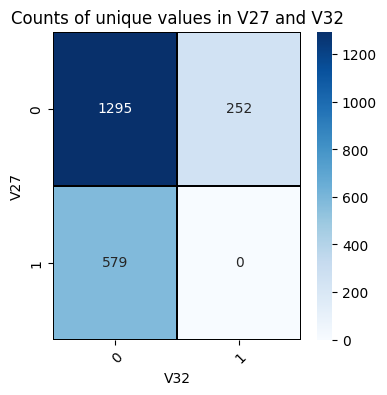

### Columns(s): "V31" AND "V32"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"V31"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"V32"&nbsp;value:&nbsp;0

**Examples**:

,V31,V32
0,0,0
1,1,0
2,1,0
4,0,0
17,0,1
28,0,1
955,0,1
1123,0,0
1900,1,0
2021,0,1


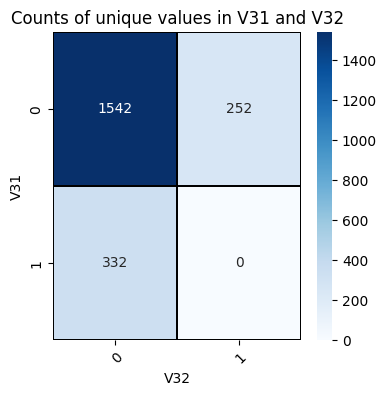

....................................................................................................


### SAME_VALUES

### Columns(s): "V4" AND "V5"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;values&nbsp;in&nbsp;"V5"&nbsp;are&nbsp;consistently&nbsp;the&nbsp;same&nbsp;as&nbsp;those&nbsp;in&nbsp;"V4"

**Examples**:

,V4,V5
0,120,120
1,132,132
2,133,133
7,122,122
14,130,130
21,128,128
59,144,144
62,142,142
66,138,138
99,125,125


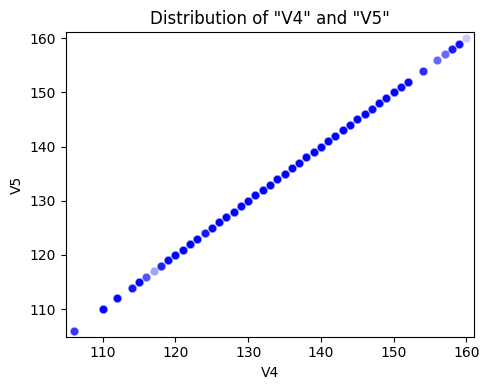

In [14]:
demo_test("cardiotocography", test_id_arr=['BINARY_IMPLIES', 'SAME_VALUES', 'SIMILAR_WRT_DIFF'])

In [15]:
demo_test("Click_prediction_small", test_id_arr=['ROUNDING'], issue_id_arr=[3])

,impression,ad_id,advertiser_id,depth,position,keyword_id,title_id,description_id,user_id
0,3,20711339,27500,2,2,2846,12631,26225,1887952
1,1,10398727,23808,2,2,14133,19101,18378,7665680
2,1,3827183,23792,1,1,5348,61,77,66280
3,2,4427867,28622,1,1,62466,127249,170983,0
4,2,1983809,11810,3,2,8139,37594,2339,290



Data consistency check complete.
Analysed 1,496,391 rows, 9 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 5 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 96 row(s) with at least one exception.
Flagged 5 column(s) with at least one exception.


### Columns(s): description_id

**Issue&nbsp;ID**:&nbsp;3

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;4&nbsp;(0.0003%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,description_id,Number Zeros
30,7,0
38,11,0
101,4,0
106,5,0
245,3,0
254,8,0
401,0,1
414,1,0
480,6,0
485,2,0


**Flagged&nbsp;values**:

,description_id,Number Zeros
208007,200000,5
1102007,100000,5
1244349,1700000,5
1299793,300000,5


,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912



Data consistency check complete.
Analysed 45,312 rows, 8 columns
Executed 1 tests.

Patterns without Exceptions:
Found 1 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 6 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 87 row(s) with at least one exception.
Flagged 6 column(s) with at least one exception.



### Columns(s): transfer

**Issue&nbsp;ID**:&nbsp;5

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.0022%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,transfer
0,0.414912
17424,0.500526
17768,0.765789
18059,0.721930
18392,0.662719
18528,0.634211
20158,0.678070
20504,0.838158
28140,0.841667
31176,0.857018


**Flagged&nbsp;values**:

,transfer
22058,0.000000


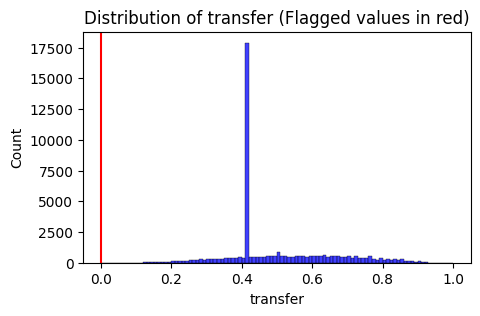

In [16]:
demo_test("electricity", test_id_arr=['NON_ZERO'], issue_id_arr=[5])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46



Data consistency check complete.
Analysed 14,980 rows, 14 columns
Executed 3 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 85 patterns with exceptions
3 tests (100.00% of tests) flagged at least one exception each.
Flagged 280 row(s) with at least one exception.
Flagged 14 column(s) with at least one exception.
....................................................................................................


### SIMILAR_PREVIOUS

### Columns(s): V2

**Issue&nbsp;ID**:&nbsp;1

...

,V2
3186,4017.440000
3187,4015.900000
3188,4016.410000
3189,4012.310000
3190,4012.820000
3191,4021.030000
3192,4022.560000
3193,4019.490000
3194,4022.050000
3195,4021.540000


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,V2
898,3797.950000
899,4005.130000
2596,4033.850000
4354,4001.540000
10325,3992.820000
10326,3959.490000
10386,2830.770000
10387,3959.490000
11509,5500.510000
11510,3991.280000


Showing&nbsp;a&nbsp;flagged&nbsp;example&nbsp;(row&nbsp;898)&nbsp;with&nbsp;5&nbsp;rows&nbsp;before&nbsp;and&nbsp;5&nbsp;rows&nbsp;after&nbsp;(if&nbsp;available)&nbsp;the&nbsp;flagged&nbsp;row

,V2
893,4011.280000
894,4008.720000
895,4004.100000
896,4003.590000
897,4007.690000
898,3797.950000
899,4005.130000
900,4003.080000
901,4009.740000
902,4020.510000


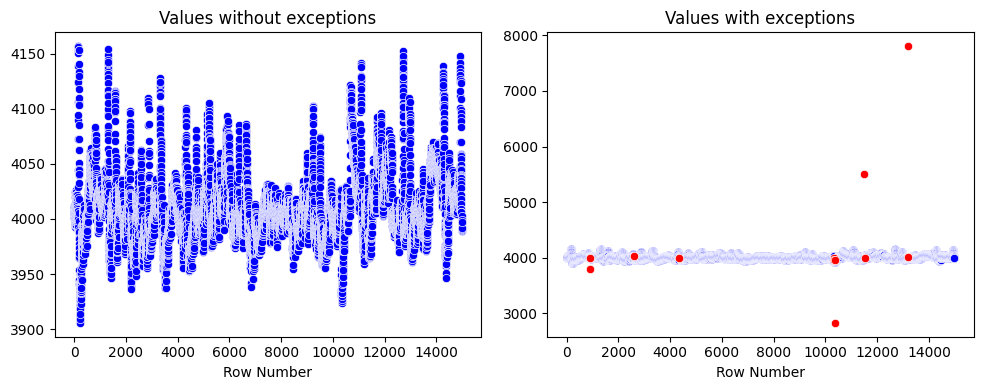

....................................................................................................


### SIMILAR_WRT_DIFF

### Columns(s): "V2" AND "V10"

**Issue&nbsp;ID**:&nbsp;28

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;4&nbsp;(0.0267%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,V2,V10,DIFF
1,4004.620000,4226.670000,-222.050000
7,4006.670000,4230.260000,-223.590000
14,4006.150000,4225.130000,-218.980000
15,4003.590000,4224.620000,-221.030000
16,3997.950000,4226.150000,-228.200000
20,4005.640000,4222.560000,-216.920000
103,4001.540000,4227.180000,-225.640000
313,3969.740000,4229.230000,-259.490000
316,3971.790000,4227.690000,-255.900000
485,3996.920000,4228.210000,-231.290000


**Flagged&nbsp;values**:

,V2,V10,DIFF
898,3797.950000,6215.380000,-2417.430000
10386,2830.770000,1816.410000,1014.360000
11509,5500.510000,3914.870000,1585.640000
13179,7804.620000,6674.360000,1130.260000


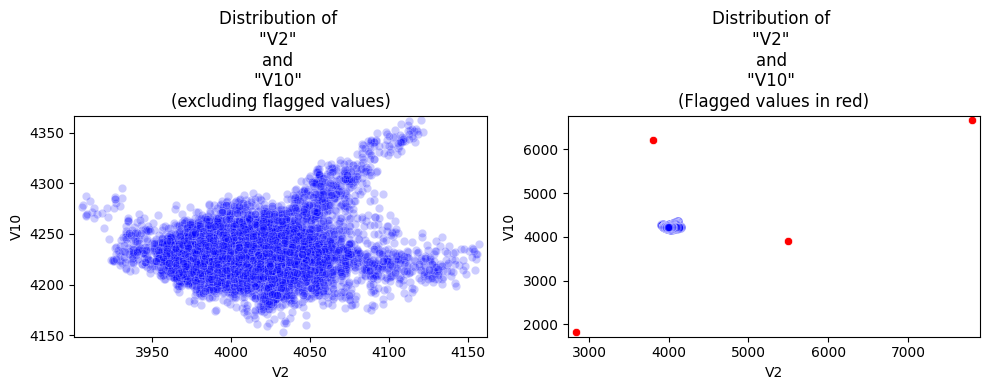

....................................................................................................


### CONSTANT_RATIO

### Columns(s): "V5" AND "V8"

**Issue&nbsp;ID**:&nbsp;81

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;53&nbsp;(0.3538%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,V5,V8,DIVISION RESULTS
7,4344.100000,4614.870000,0.941327
11,4339.490000,4615.380000,0.940224
18,4342.050000,4610.770000,0.941719
20,4345.130000,4612.820000,0.941968
32,4330.770000,4611.790000,0.939065
50,4341.030000,4612.310000,0.941183
51,4337.440000,4609.740000,0.940929
52,4336.920000,4614.360000,0.939875
55,4336.920000,4613.330000,0.940084
87,4334.870000,4613.850000,0.939534


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,V5,V8,DIVISION RESULTS
196,4317.950000,4637.950000,0.931004
204,4310.260000,4631.280000,0.930684
213,4321.030000,4653.850000,0.928485
214,4318.460000,4658.460000,0.927015
215,4325.640000,4654.360000,0.929374
217,4322.560000,4650.260000,0.929531
218,4313.330000,4646.670000,0.928263
219,4316.410000,4644.100000,0.929440
220,4321.540000,4650.260000,0.929311
221,4319.490000,4660.510000,0.926828


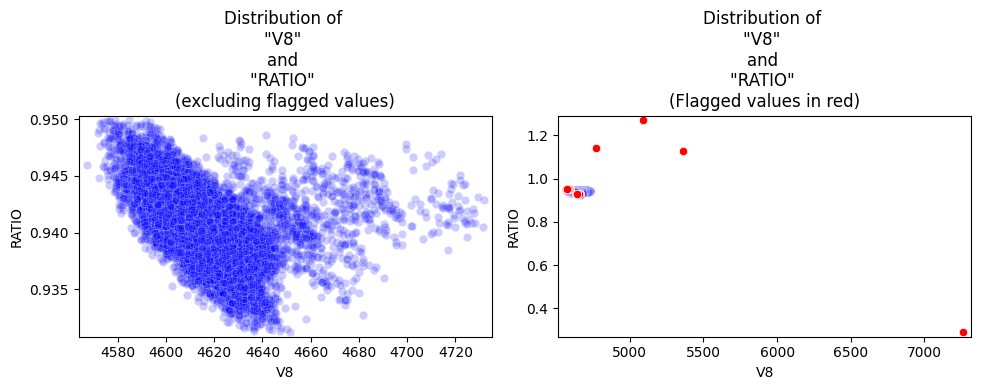

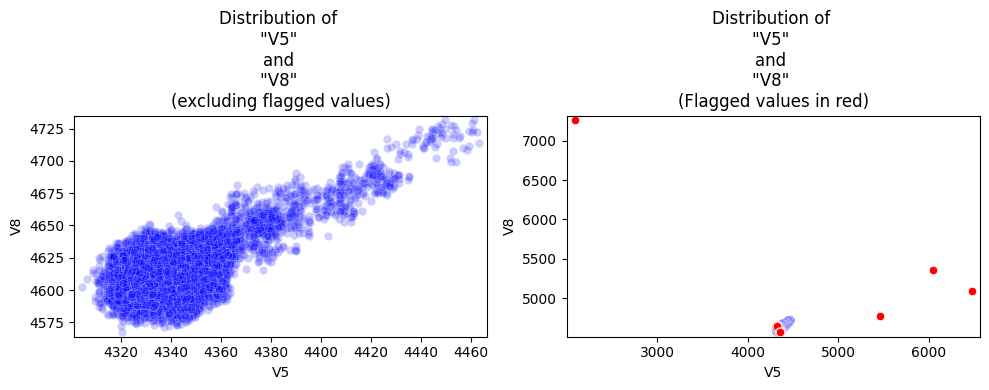

In [17]:
demo_test("eeg-eye-state", test_id_arr=['SIMILAR_PREVIOUS', 'SIMILAR_WRT_DIFF', 'CONSTANT_RATIO'], issue_id_arr=[81, 1, 28])

,Abbrev,Rep,Locality,Map_Ref,Latitude,Altitude,Rainfall,Frosts,Year,Sp,PMCno,DBH,Ht,Surv,Vig,Ins_res,Stem_Fm,Crown_Fm,Brnch_Fm
0,Cra,1,Central_Hawkes_Bay,N135_382/137,39__38,100,850,-2,1980,co,1520.0,18.45,9.96,40.0,4.0,3.0,3.5,4.0,3.5
1,Cra,1,Central_Hawkes_Bay,N135_382/137,39__38,100,850,-2,1980,fr,1487.0,13.15,9.65,90.0,4.5,4.0,3.5,3.5,3.0
2,Cra,1,Central_Hawkes_Bay,N135_382/137,39__38,100,850,-2,1980,ma,1362.0,10.32,6.50,50.0,2.3,2.5,3.0,3.5,3.0
3,Cra,1,Central_Hawkes_Bay,N135_382/137,39__38,100,850,-2,1980,nd,1596.0,14.80,9.48,70.0,3.7,3.0,3.3,4.0,3.5
4,Cra,1,Central_Hawkes_Bay,N135_382/137,39__38,100,850,-2,1980,ni,2088.0,14.50,10.78,90.0,4.0,2.7,3.3,3.0,3.0



Data consistency check complete.
Analysed 736 rows, 19 columns
Executed 3 tests.

Patterns without Exceptions:
Found 4 patterns without exceptions
3 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'GROUPED_STRINGS',&nbsp;'CORRELATED_ALPHA_ORDER',&nbsp;'POSITION_NON-ALPHANUMERIC'

....................................................................................................


### GROUPED_STRINGS

...

### Columns(s): "Map_Ref" AND "Latitude"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"Map_Ref"&nbsp;is&nbsp;consistently&nbsp;similar,&nbsp;with&nbsp;regards&nbsp;to&nbsp;percentile,&nbsp;to&nbsp;"Latitude"

**Examples**:

,Map_Ref,Latitude,Percentile Column 1,Percentile Column 2
0,N135_382/137,39__38,0.053668,0.053668
30,N116_848/985,39__00,0.016984,0.016984
76,N142_377/957,39__50,0.207201,0.207201
146,N158_344/626,40__57,0.607337,0.576766
211,N162_081/300,41__12,0.756793,0.828804
329,N151_912/221,40__36,0.399457,0.402853
437,N162_097/424,41__08,0.842391,0.743207
490,N166_063/197,41__16,0.935462,0.935462
574,N146_273/737,40__00,0.322011,0.292120
662,N141_295/063,39__43,0.116848,0.116848


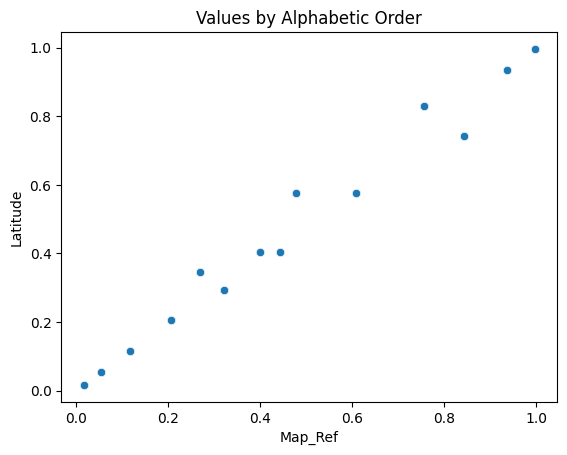

....................................................................................................


### POSITION_NON-ALPHANUMERIC

### Columns(s): Map_Ref

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;contains&nbsp;values&nbsp;consistently&nbsp;with&nbsp;'/'&nbsp;in&nbsp;position&nbsp;4&nbsp;from&nbsp;the&nbsp;end

...

### Columns(s): Latitude

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;contains&nbsp;values&nbsp;consistently&nbsp;with&nbsp;'_'&nbsp;in&nbsp;position&nbsp;3

**Examples**:

,Latitude
0,39__38
30,39__00
76,39__50
146,40__57
211,41__12
329,40__36
437,41__08
490,41__16
574,40__00
662,39__43


In [18]:
demo_test("eucalyptus", test_id_arr=['GROUPED_STRINGS', 'CORRELATED_ALPHA_ORDER', 'POSITION_NON-ALPHANUMERIC'])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989303,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


Error ALL_POS_OR_ALL_NEG is not a valid test



Data consistency check complete.
Analysed 10,299 rows, 561 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 36 row(s) with at least one exception.
Flagged 1 column(s) with at least one exception.
....................................................................................................


### VERY_SMALL_ABS

### Columns(s): V103

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;36&nbsp;(0.3495%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,V103
1,-0.875096
4,-0.850744
5,-0.778718
6,-0.787925
7,-0.807351
16,-0.839274
18,-0.828235
19,-0.862673
37,-0.817601
49,-0.797465


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,V103
67,0.037543
69,-0.030380
238,-0.035489
356,0.016084
357,0.006775
692,-0.036489
739,-0.009230
1049,0.007264
1223,-0.023924
1523,0.025068


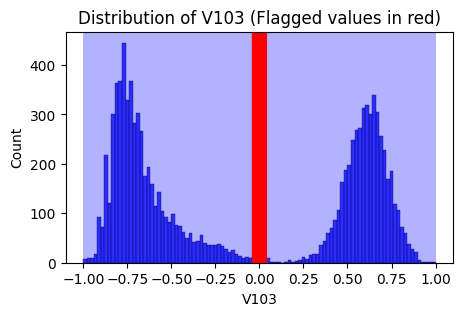

In [19]:
demo_test("har", test_id_arr=['VERY_SMALL_ABS', 'ALL_POS_OR_ALL_NEG'], issue_id_arr=[0, 1])

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source
0,41.0,F,f,f,f,f,f,f,f,f,...,2.5,t,125.0,t,1.14,t,109.0,f,NaN,SVHC
1,23.0,F,f,f,f,f,f,f,f,f,...,2.0,t,102.0,f,NaN,f,NaN,f,NaN,other
2,46.0,M,f,f,f,f,f,f,f,f,...,NaN,t,109.0,t,0.91,t,120.0,f,NaN,other
3,70.0,F,t,f,f,f,f,f,f,f,...,1.9,t,175.0,f,NaN,f,NaN,f,NaN,other
4,70.0,F,f,f,f,f,f,f,f,f,...,1.2,t,61.0,t,0.87,t,70.0,f,NaN,SVI



Data consistency check complete.
Analysed 3,772 rows, 27 columns
Executed 2 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 3 patterns with exceptions
2 tests (100.00% of tests) flagged at least one exception each.
Flagged 25 row(s) with at least one exception.
Flagged 6 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'DECISION_TREE_CLASSIFIER',&nbsp;'SAME_VALUES'

....................................................................................................


### DECISION_TREE_CLASSIFIER

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.0530%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,T4U_measured,FTI_measured
0,t,t
1,f,f
2,t,t
3,f,f
4,t,t
5,t,t
6,t,t
27,f,f
39,f,f
54,f,f


**Flagged&nbsp;values**:

,T4U_measured,FTI_measured
765,f,t
1515,f,t


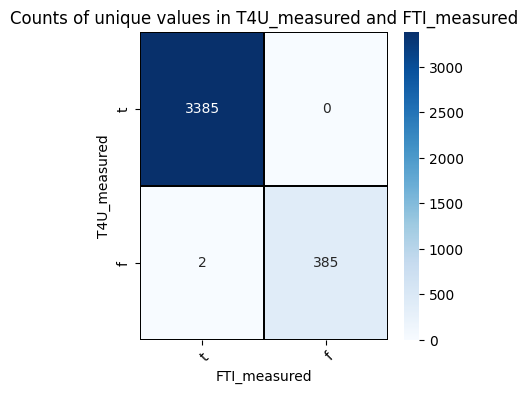

In [20]:
demo_test("hypothyroid", test_id_arr=['DECISION_TREE_CLASSIFIER', 'SAME_VALUES'])

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f608,f609,f610,f611,f612,f613,f614,f615,f616,f617
0,-0.4394,-0.0930,0.1718,0.4620,0.6226,0.4704,0.3578,0.0478,-0.1184,-0.2310,...,0.3334,0.4102,0.2052,0.3846,0.3590,0.5898,0.3334,0.6410,0.5898,-0.4872
1,-0.4348,-0.1198,0.2474,0.4036,0.5026,0.6328,0.4948,0.0338,-0.0520,-0.1302,...,0.2272,0.0000,0.2954,0.2046,0.4772,0.0454,0.2046,0.4318,0.4546,-0.0910
2,-0.2330,0.2124,0.5014,0.5222,-0.3422,-0.5840,-0.7168,-0.6342,-0.8614,-0.8318,...,0.0952,-0.1112,-0.0476,-0.1746,0.0318,-0.0476,0.1112,0.2540,0.1588,-0.4762
3,-0.3808,-0.0096,0.2602,0.2554,-0.4290,-0.6746,-0.6868,-0.6650,-0.8410,-0.9614,...,0.0648,-0.0504,-0.0360,-0.1224,0.1366,0.2950,0.0792,-0.0072,0.0936,-0.1510
4,-0.3412,0.0946,0.6082,0.6216,-0.1622,-0.3784,-0.4324,-0.4358,-0.4966,-0.5406,...,0.2812,0.1562,0.3124,0.2500,-0.0938,0.1562,0.3124,0.3124,0.2188,-0.2500



Data consistency check complete.
Analysed 7,797 rows, 617 columns
Executed 1 tests.

Patterns without Exceptions:
Found 3 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): "f578" AND "f579"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"f578"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"f579"&nbsp;value:&nbsp;-1

**Examples**:

,f578,f579
0,-1,1
1,1,-1
2,-1,-1
3,-1,-1
4,-1,1
9,1,-1
2892,-1,-1
3466,1,-1
3584,-1,-1
5991,-1,-1


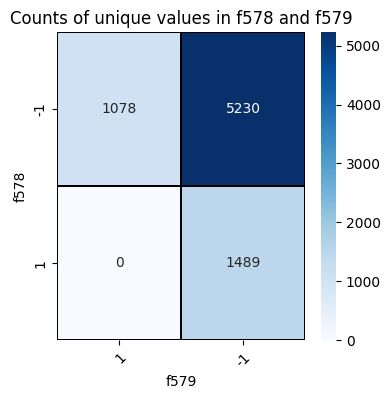

### Columns(s): "f578" AND "f580"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"f578"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"f580"&nbsp;value:&nbsp;-1

**Examples**:

,f578,f580
0,-1,-1
1,1,-1
2,-1,1
3,-1,1
4,-1,-1
9,1,-1
517,1,-1
2703,-1,-1
4305,-1,1
6550,-1,1


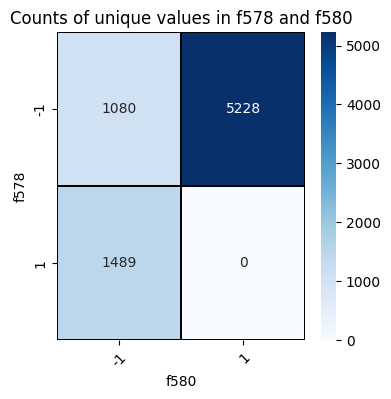

### Columns(s): "f579" AND "f580"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"f579"&nbsp;value:&nbsp;1&nbsp;consistently&nbsp;implies&nbsp;"f580"&nbsp;value:&nbsp;-1

**Examples**:

,f579,f580
0,1,-1
1,-1,-1
2,-1,1
3,-1,1
4,1,-1
9,-1,-1
2039,-1,-1
2792,-1,-1
3438,-1,1
4252,-1,1


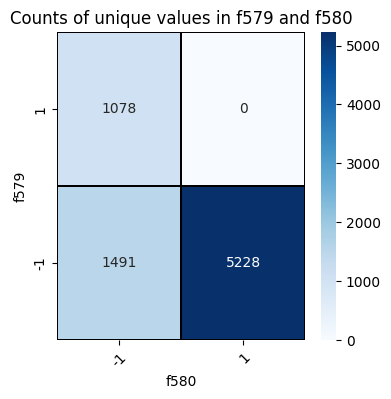

In [21]:
demo_test("Isolet", test_id_arr=['BINARY_IMPLIES'])

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f608,f609,f610,f611,f612,f613,f614,f615,f616,f617
0,-0.4394,-0.0930,0.1718,0.4620,0.6226,0.4704,0.3578,0.0478,-0.1184,-0.2310,...,0.3334,0.4102,0.2052,0.3846,0.3590,0.5898,0.3334,0.6410,0.5898,-0.4872
1,-0.4348,-0.1198,0.2474,0.4036,0.5026,0.6328,0.4948,0.0338,-0.0520,-0.1302,...,0.2272,0.0000,0.2954,0.2046,0.4772,0.0454,0.2046,0.4318,0.4546,-0.0910
2,-0.2330,0.2124,0.5014,0.5222,-0.3422,-0.5840,-0.7168,-0.6342,-0.8614,-0.8318,...,0.0952,-0.1112,-0.0476,-0.1746,0.0318,-0.0476,0.1112,0.2540,0.1588,-0.4762
3,-0.3808,-0.0096,0.2602,0.2554,-0.4290,-0.6746,-0.6868,-0.6650,-0.8410,-0.9614,...,0.0648,-0.0504,-0.0360,-0.1224,0.1366,0.2950,0.0792,-0.0072,0.0936,-0.1510
4,-0.3412,0.0946,0.6082,0.6216,-0.1622,-0.3784,-0.4324,-0.4358,-0.4966,-0.5406,...,0.2812,0.1562,0.3124,0.2500,-0.0938,0.1562,0.3124,0.3124,0.2188,-0.2500



Data consistency check complete.
Analysed 7,797 rows, 617 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 19 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 44 row(s) with at least one exception.
Flagged 22 column(s) with at least one exception.



### Columns(s): "f579" AND "f503"

**Issue&nbsp;ID**:&nbsp;5

Unusual&nbsp;values&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;4&nbsp;(0.0513%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,f579,f503
32,1,1.000000
77,-1,0.333400
127,-1,0.666600
159,-1,0.600000
271,-1,0.428600
320,-1,0.000000
411,-1,0.200000
713,-1,0.500000
721,-1,0.555600
786,-1,0.750000


**Flagged&nbsp;values**:

,f579,f503
22,1,-0.363200
218,1,-0.558200
5667,1,-0.373400
6290,1,-0.448200


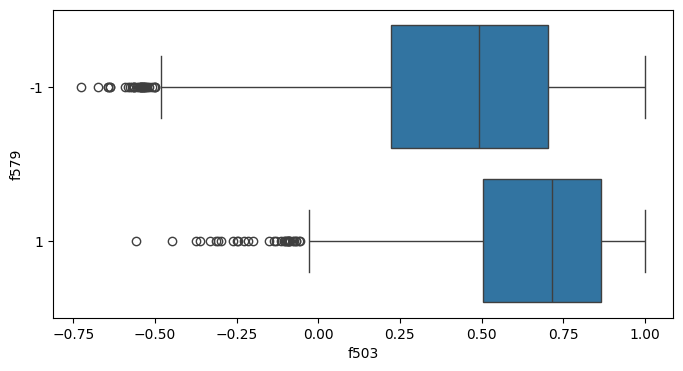

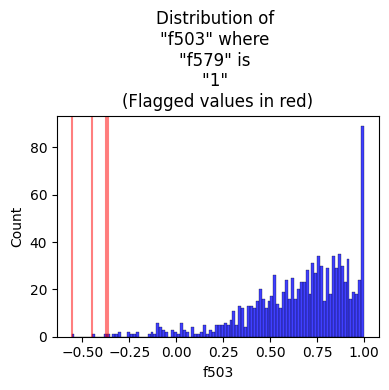

In [22]:
demo_test("Isolet", test_id_arr=['SMALL_GIVEN_VALUE'], issue_id_arr=[5])

,utterance,frame,coefficient1,coefficient2,coefficient3,coefficient4,coefficient5,coefficient6,coefficient7,coefficient8,coefficient9,coefficient10,coefficient11,coefficient12
0,1,1,1.860936,-0.207383,0.261557,-0.214562,-0.171253,-0.118167,-0.277557,0.025668,0.126701,-0.306756,-0.213076,0.088728
1,1,2,1.891651,-0.193249,0.235363,-0.249118,-0.112890,-0.112238,-0.311997,-0.027122,0.171457,-0.289431,-0.247722,0.093011
2,1,3,1.939205,-0.239664,0.258561,-0.291458,-0.041053,-0.102034,-0.383300,0.019013,0.169510,-0.314894,-0.227908,0.074638
3,1,4,1.717517,-0.218572,0.217119,-0.228186,-0.018608,-0.137624,-0.403318,-0.009643,0.164607,-0.323267,-0.210105,0.098098
4,1,5,1.741191,-0.279891,0.196583,-0.236377,-0.032012,-0.090612,-0.363134,-0.012571,0.124298,-0.351171,-0.216545,0.113899



Data consistency check complete.
Analysed 9,961 rows, 14 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 17 row(s) with at least one exception.
Flagged 1 column(s) with at least one exception.



### Columns(s): utterance

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

,utterance
4265,30
4266,30
4267,30
4268,30
4269,30
4270,30
4271,30
4272,30
4273,30


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,utterance
542,1
1007,1
1431,1
2037,1
2434,1
2957,1
3463,1
3840,1
4274,1
4828,1


Showing&nbsp;a&nbsp;flagged&nbsp;example&nbsp;(row&nbsp;542)&nbsp;with&nbsp;5&nbsp;rows&nbsp;before&nbsp;and&nbsp;5&nbsp;rows&nbsp;after&nbsp;(if&nbsp;available)&nbsp;the&nbsp;flagged&nbsp;row

,utterance
537,30
538,30
539,30
540,30
541,30
542,1
543,1
544,1
545,1
546,1


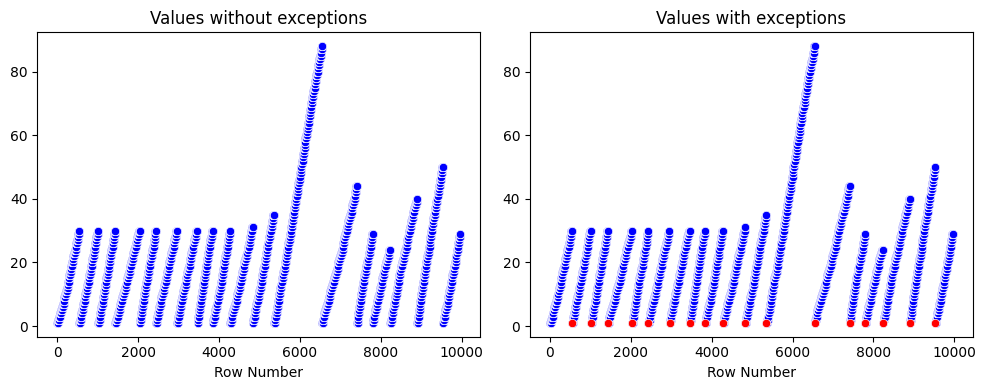

In [23]:
demo_test("JapaneseVowels", test_id_arr=['COLUMN_ORDERED_ASC'])

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,1.30,2,2,2,2,1.2,1.2,1.2,1.2,1.4
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1,1,1,1,1.0,1.0,1.0,1.0,1.0
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,1279.39,51,10,8,1,17.0,36.0,112.0,86.0,13.0
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,4122.37,129,29,28,2,17.0,135.0,329.0,271.0,5.0
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,572.07,28,1,6,0,11.0,16.0,76.0,50.0,7.0



Data consistency check complete.
Analysed 10,885 rows, 21 columns
Executed 2 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 3 patterns with exceptions
2 tests (100.00% of tests) flagged at least one exception each.
Flagged 49 row(s) with at least one exception.
Flagged 7 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'SIMILAR_TO_DIFF',&nbsp;'SIMILAR_TO_PRODUCT'

....................................................................................................


### SIMILAR_TO_DIFF

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;35&nbsp;(0.3215%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,n,total_Opnd,total_Op,ABSOLUTE DIFFERENCE
6,0.000000,0.000000,0.000000,0.000000
7,16.000000,7.000000,9.000000,9.000000
16,9.000000,4.000000,5.000000,5.000000
55,15.000000,7.000000,8.000000,8.000000
61,17.000000,7.000000,10.000000,10.000000
79,11.000000,5.000000,6.000000,6.000000
86,18.000000,11.000000,7.000000,7.000000
159,7.000000,3.000000,4.000000,4.000000
174,17.000000,6.000000,11.000000,11.000000
374,5.000000,2.000000,3.000000,3.000000


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,n,total_Opnd,total_Op,ABSOLUTE DIFFERENCE
0,1.300000,1.200000,1.200000,0.100000
1,1.000000,1.000000,1.000000,0.000000
67,135.000000,74.000000,116.000000,61.000000
209,498.000000,147.000000,210.000000,351.000000
411,98.000000,49.000000,61.000000,49.000000
890,38.000000,18.000000,23.000000,20.000000
1241,137.000000,54.000000,73.000000,83.000000
1242,138.000000,54.000000,74.000000,84.000000
1438,232.000000,58.000000,138.000000,174.000000
1550,786.000000,320.000000,522.000000,466.000000


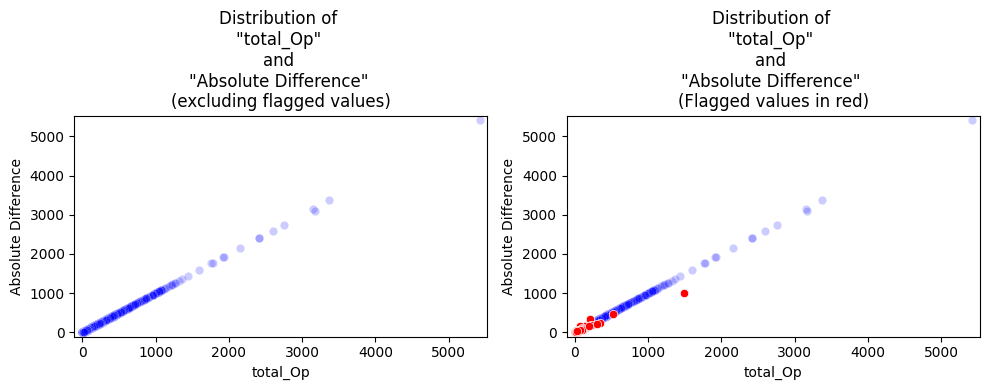

....................................................................................................


### SIMILAR_TO_PRODUCT

### Columns(s): "v" AND "d" AND "e"

**Issue&nbsp;ID**:&nbsp;1

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.0092%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,v,d,e,PRODUCT
6,0.000000,0.000000,0.000000,0.000000
16,27.000000,2.000000,54.000000,54.000000
55,51.890000,2.920000,151.350000,151.518800
159,19.650000,2.000000,39.300000,39.300000
374,11.610000,1.500000,17.410000,17.415000
410,31.700000,2.500000,79.250000,79.250000
414,8.000000,1.500000,12.000000,12.000000
445,15.510000,2.000000,31.020000,31.020000
482,19.650000,2.500000,49.130000,49.125000
613,48.430000,3.600000,174.360000,174.348000


**Flagged&nbsp;values**:

,v,d,e,PRODUCT
0,1.300000,1.300000,1.300000,1.690000


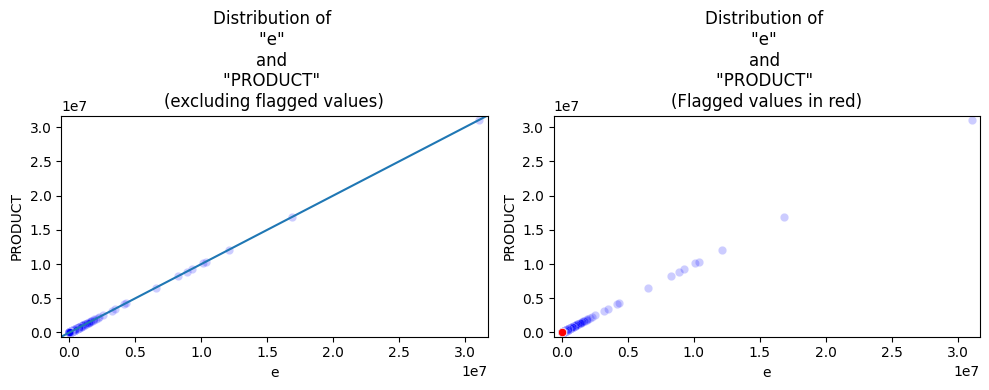

### Columns(s): "d" AND "i" AND "v"

**Issue&nbsp;ID**:&nbsp;2

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;"v"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(within&nbsp;10%)&nbsp;to&nbsp;the&nbsp;product&nbsp;of&nbsp;"d"&nbsp;and&nbsp;"i",&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;15&nbsp;(0.1378%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,d,i,v,PRODUCT
6,0.000000,0.000000,0.000000,0.000000
16,2.000000,13.500000,27.000000,27.000000
55,2.920000,17.790000,51.890000,51.946800
79,3.120000,11.160000,34.870000,34.819200
159,2.000000,9.830000,19.650000,19.660000
240,4.380000,11.070000,48.430000,48.486600
374,1.500000,7.740000,11.610000,11.610000
410,2.500000,12.680000,31.700000,31.700000
412,1.500000,10.340000,15.510000,15.510000
414,1.500000,5.330000,8.000000,7.995000


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,d,i,v,PRODUCT
0,1.300000,1.300000,1.300000,1.690000
2117,0.000000,0.000000,2.000000,0.000000
2140,0.000000,0.000000,2.000000,0.000000
2775,0.000000,0.000000,4.750000,0.000000
3616,0.000000,0.000000,30.190000,0.000000
4006,0.000000,0.000000,4.750000,0.000000
4297,0.000000,0.000000,4.750000,0.000000
4463,0.000000,0.000000,4.750000,0.000000
6001,0.000000,0.000000,4.750000,0.000000
6002,0.000000,0.000000,4.750000,0.000000


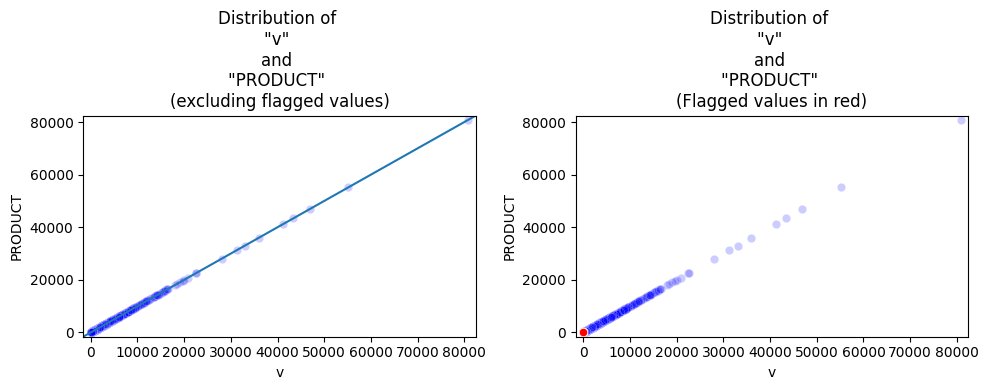

In [24]:
demo_test("jm1", test_id_arr=['SIMILAR_TO_DIFF', 'SIMILAR_TO_PRODUCT']) 

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,1.30,2,2,2,2,1.2,1.2,1.2,1.2,1.4
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1,1,1,1,1.0,1.0,1.0,1.0,1.0
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,1279.39,51,10,8,1,17.0,36.0,112.0,86.0,13.0
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,4122.37,129,29,28,2,17.0,135.0,329.0,271.0,5.0
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,572.07,28,1,6,0,11.0,16.0,76.0,50.0,7.0



Data consistency check complete.
Analysed 10,885 rows, 21 columns
Executed 2 tests.

Patterns without Exceptions:
Found 2 patterns without exceptions
1 tests (50.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 17 patterns with exceptions
2 tests (100.00% of tests) flagged at least one exception each.
Flagged 7 row(s) with at least one exception.
Flagged 12 column(s) with at least one exception.
....................................................................................................


### RARE_DECIMALS

### Columns(s): v(g)

**Issue&nbsp;ID**:&nbsp;1

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;3&nbsp;(0.0276%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,v(g),branchCount,Column 1 Percentile,Column 2 Percentile
1,1.000000,1.000000,0.121232,0.121186
2,7.000000,13.000000,0.760662,0.767050
3,3.000000,5.000000,0.465257,0.468474
4,4.000000,7.000000,0.571094,0.577941
5,2.000000,3.000000,0.323024,0.322794
6,9.000000,17.000000,0.821048,0.828033
10,10.000000,19.000000,0.844256,0.850460
14,8.000000,15.000000,0.794439,0.801425
21,6.000000,11.000000,0.714246,0.720267
27,5.000000,9.000000,0.651103,0.658042


**Flagged&nbsp;values**:

,v(g),branchCount,Column 1 Percentile,Column 2 Percentile
1963,3.000000,1.000000,0.465257,0.121186
2849,1.000000,93.000000,0.121232,0.990625
3058,1.000000,25.000000,0.121232,0.900138


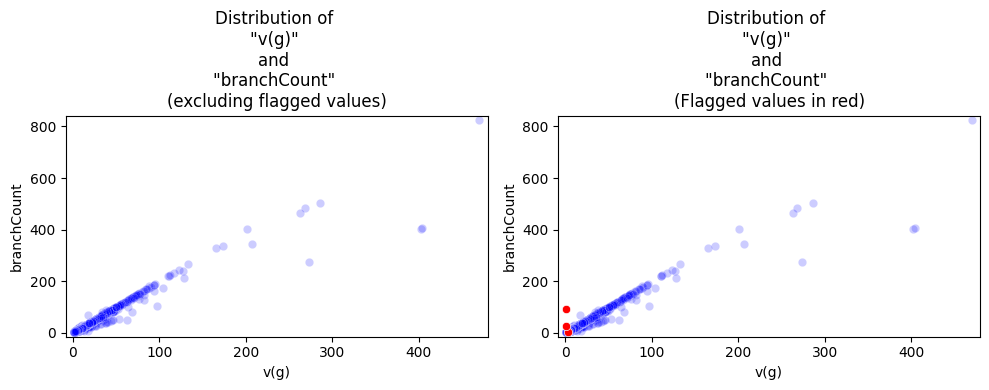

### Columns(s): "n" AND "b"

**Issue&nbsp;ID**:&nbsp;11

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;"n"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(with&nbsp;0.0%&nbsp;identical&nbsp;values),&nbsp;with&nbsp;respect&nbsp;to&nbsp;rank,&nbsp;to&nbsp;"b"&nbsp;with&nbsp;a<br>Spearman&nbsp;correlation&nbsp;of&nbsp;0.9967554420996558,&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.0184%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,n,b,Column 1 Percentile,Column 2 Percentile
6,0.000000,0.000000,0.061277,0.080110
7,16.000000,0.020000,0.269867,0.273358
12,37.000000,0.060000,0.426367,0.453927
16,9.000000,0.010000,0.197106,0.200184
30,31.000000,0.040000,0.386679,0.375057
38,21.000000,0.030000,0.312540,0.330455
40,52.000000,0.070000,0.518512,0.490492
41,51.000000,0.080000,0.513459,0.523243
69,62.000000,0.090000,0.570877,0.553927
297,32.000000,0.050000,0.392972,0.415113


**Flagged&nbsp;values**:

,n,b,Column 1 Percentile,Column 2 Percentile
0,1.300000,1.300000,0.124667,0.972577
1,1.000000,1.000000,0.123565,0.958980


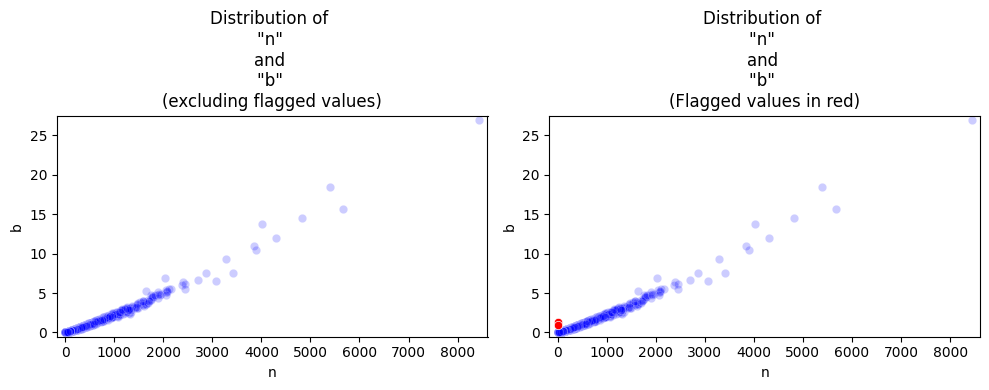

In [25]:
demo_test("jm1", test_id_arr=['RARE_DECIMALS', 'CORRELATED_NUMERIC'], issue_id_arr=[1, 10, 11])

In [26]:
demo_test("kc2", test_id_arr=['LINEAR_REGRESSION'])

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,t,lOCode,lOComment,lOBlank,lOCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,1.30,2,2,2,2,1.2,1.2,1.2,1.2,1.4
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1,1,1,1,1.0,1.0,1.0,1.0,1.0
2,415.0,59.0,50.0,51.0,1159.0,8411.31,0.01,103.53,81.24,870848.58,...,48380.48,359,35,9,10,47.0,106.0,692.0,467.0,106.0
3,230.0,33.0,10.0,16.0,575.0,3732.82,0.03,39.82,93.74,148644.06,...,8258.00,174,15,34,5,23.0,67.0,343.0,232.0,65.0
4,175.0,26.0,12.0,13.0,500.0,3123.96,0.03,29.48,105.96,92103.07,...,5116.84,142,7,19,4,18.0,58.0,310.0,190.0,51.0



Data consistency check complete.
Analysed 522 rows, 21 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.
No patterns or exceptions to display.


,molecule_name,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,f166
0,MUSK-211,46,-108,-60,-69,-117,49,38,-161,-8,...,-244,-308,52,-7,39,126,156,-50,-112,96
1,MUSK-211,41,-188,-145,22,-117,-6,57,-171,-39,...,-235,-59,-2,52,103,136,169,-61,-136,79
2,MUSK-211,46,-194,-145,28,-117,73,57,-168,-39,...,-238,-134,-154,57,143,142,165,-67,-145,39
3,MUSK-211,41,-188,-145,22,-117,-7,57,-170,-39,...,-236,-60,-4,52,104,136,168,-60,-135,80
4,MUSK-211,41,-188,-145,22,-117,-7,57,-170,-39,...,-236,-60,-4,52,104,137,168,-60,-135,80


Error ALL_POS_OR_ALL_NEG is not a valid test



Data consistency check complete.
Analysed 6,598 rows, 167 columns
Executed 2 tests.

Patterns without Exceptions:
Found 2 patterns without exceptions
1 tests (50.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 11 patterns with exceptions
2 tests (100.00% of tests) flagged at least one exception each.
Flagged 136 row(s) with at least one exception.
Flagged 125 column(s) with at least one exception.
....................................................................................................


### LINEAR_REGRESSION

### Columns(s): "f10" AND "f14" AND "f15" AND "f35" AND "f44" AND "f45" AND "f46" AND "f49" AND "f51" AND "f60" AND "f65" AND "f73" AND "f74" AND "f79" AND "f80" AND "f83" AND "f89" AND "f93" AND "f102" AND "f103" AND "f106" AND "f111" AND "f112" AND "f115" AND "f117" AND "f121" AND "f122" AND "f128" AND "f134" AND "f140" AND "f159" AND "f12"

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;5&nbsp;(0.0758%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,f10,f14,f15,f35,f44,f45,f46,f49,f51,f60,...,f115,f117,f121,f122,f128,f134,f140,f159,f12,PREDICTION
5,-22,-284,-283,-38,-318,-243,-332,-106,-72,51,...,-23,128,61,122,63,-126,-33,-156,-112,-112.977079
36,-100,-285,-281,-59,-304,-279,-288,-137,-142,26,...,15,100,66,130,88,-165,-31,-1,-214,-210.635046
75,-102,-286,-283,-60,-307,-278,-293,-138,-139,27,...,13,100,69,133,88,-163,-32,-4,-212,-209.326381
96,-24,-288,-284,-39,-324,-244,-334,-104,-73,51,...,-22,124,63,110,63,-129,-30,-155,-113,-113.922209
305,-26,-294,-284,-152,-297,-281,-277,-168,-141,36,...,-7,110,80,151,55,-174,-99,-128,-215,-211.195320
568,-76,-119,-91,-42,-77,-82,-108,-46,-69,-133,...,-176,-57,-102,135,-159,-72,-55,-204,-22,-21.144441
573,-72,-125,-85,-22,-81,-84,-124,-40,-75,-127,...,-174,-91,-88,141,-129,-80,-55,-209,-25,-26.570833
579,-74,-120,-90,-23,-78,-82,-112,-45,-70,-135,...,-175,-96,-115,-26,-168,-73,-55,-205,-23,-20.688025
586,-72,-122,-89,-15,-81,-82,-116,-45,-72,-133,...,-174,-94,-115,-54,-169,-76,-55,-206,-24,-21.951380
1307,-22,-276,-285,-144,-297,-245,-328,-107,-73,40,...,-1,112,82,149,56,-128,-33,-137,-114,-114.137090


**Flagged&nbsp;values**:

,f10,f14,f15,f35,f44,f45,f46,f49,f51,f60,...,f115,f117,f121,f122,f128,f134,f140,f159,f12,PREDICTION
1948,-60,87,28,-158,54,136,-148,17,121,-5,...,-37,146,103,52,89,160,-177,28,181,246.152597
1949,-61,70,30,-122,48,136,-167,39,118,0,...,-42,149,104,50,87,141,-183,17,184,253.543252
1950,-27,93,33,-122,70,125,-120,25,115,15,...,-52,163,87,35,92,162,-117,20,169,232.904724
2000,-27,-69,-81,-122,-62,52,-140,222,-140,18,...,-49,165,84,37,92,-75,-47,17,119,72.376170
2015,-23,-75,-90,-157,-57,6,-114,273,-181,14,...,-48,163,82,38,95,-126,-73,29,-111,-66.120412


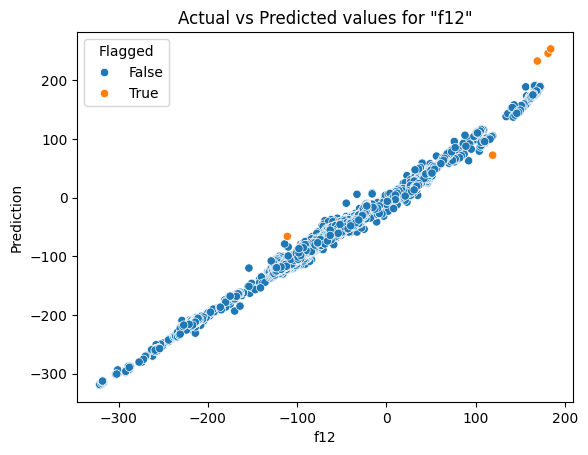

### Columns(s): "f11" AND "f29" AND "f35" AND "f43" AND "f52" AND "f57" AND "f60" AND "f65" AND "f70" AND "f71" AND "f72" AND "f74" AND "f78" AND "f79" AND "f80" AND "f82" AND "f83" AND "f86" AND "f93" AND "f98" AND "f99" AND "f105" AND "f108" AND "f110" AND "f112" AND "f113" AND "f117" AND "f120" AND "f121" AND "f123" AND "f128" AND "f129" AND "f134" AND "f137" AND "f139" AND "f142" AND "f143" AND "f150" AND "f153" AND "f156" AND "f158" AND "f159" AND "f30"

**Issue&nbsp;ID**:&nbsp;1

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;The&nbsp;column&nbsp;"f30"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression<br>formula:&nbsp;&nbsp;0.041&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f11"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f29"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f35"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f43"&nbsp;+&nbsp;&nbsp;0.10&nbsp;*&nbsp;"f52"&nbsp;+<br>0.14&nbsp;*&nbsp;"f57"&nbsp;+&nbsp;&nbsp;0.28&nbsp;*&nbsp;"f60"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f65"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f70"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f71"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f72"&nbsp;+&nbsp;&nbsp;0.04<br>*&nbsp;"f74"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f78"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"f79"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f80"&nbsp;+&nbsp;&nbsp;0.14&nbsp;*&nbsp;"f82"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f83"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*<br>"f86"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f93"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f98"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f99"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"f105"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f108"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*<br>"f110"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"f112"&nbsp;+&nbsp;&nbsp;0.07&nbsp;*&nbsp;"f113"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"f117"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f120"&nbsp;+&nbsp;&nbsp;0.52&nbsp;*&nbsp;"f121"&nbsp;+&nbsp;&nbsp;0.07<br>*&nbsp;"f123"&nbsp;+&nbsp;&nbsp;0.58&nbsp;*&nbsp;"f128"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f129"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f134"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"f137"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"f139"&nbsp;+<br>0.11&nbsp;*&nbsp;"f142"&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"f143"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"f150"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f153"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f156"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f158"&nbsp;+<br>0.05&nbsp;*&nbsp;"f159".&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original<br>values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features),&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;28&nbsp;(0.4244%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,f11,f29,f35,f43,f52,f57,f60,f65,f70,f71,...,f139,f142,f143,f150,f153,f156,f158,f159,f30,PREDICTION
0,-323,-67,-120,-33,-13,42,8,-135,23,-48,...,-41,70,17,24,-114,3,-308,52,105,106.565039
11,-317,-66,-151,-24,-27,19,12,-134,5,-55,...,4,48,2,46,-113,-73,-298,59,104,107.687550
14,-261,25,-120,-25,-14,42,42,-145,23,-48,...,-40,70,18,23,-113,4,-88,-144,68,69.415795
119,-264,26,-156,-27,-12,38,40,-146,30,-56,...,-31,62,8,54,-113,-63,-75,-132,69,70.961504
463,-50,10,-34,-128,-25,87,-186,-15,-73,-162,...,-18,-2,58,35,10,31,-255,-206,-143,-141.009390
465,-52,12,-35,-128,-25,88,-187,-13,-72,-161,...,-16,-2,58,36,8,-44,-259,-208,-145,-144.046526
468,-57,11,-32,-68,-16,62,-164,-11,-110,-167,...,-50,-30,23,-11,9,-192,-276,-209,-146,-144.974082
469,-51,10,-35,-68,-18,60,-163,-15,-110,-168,...,-49,-30,23,-14,10,31,-268,-206,-142,-142.821411
483,-52,11,-34,-74,-13,61,-167,-13,-112,-168,...,27,-35,22,-13,9,-196,-271,-207,-144,-143.891041
507,-62,10,-34,-152,-46,114,-196,-15,54,-115,...,-23,149,137,104,10,32,-257,-204,-141,-142.093065


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,f11,f29,f35,f43,f52,f57,f60,f65,f70,f71,...,f139,f142,f143,f150,f153,f156,f158,f159,f30,PREDICTION
553,-53,110,-120,-81,-198,-162,-9,-141,-41,-38,...,-190,-139,-153,-143,-107,-13,-252,-212,49,94.586821
851,-186,-2,-132,-4,-27,88,56,-116,-67,-161,...,-74,3,58,39,-112,-73,-276,-192,207,155.674660
2035,-58,-82,-157,-37,-196,-165,-49,-158,-35,-31,...,-205,-138,-153,-137,-112,-85,-256,-200,12,50.782770
2046,-70,-79,-122,-56,-199,-160,-62,-153,-41,-38,...,-204,-138,-152,-142,-113,-11,-277,-210,3,40.206229
2174,-57,-82,-157,-37,-196,-14,-49,-158,105,1,...,-205,79,-28,84,-112,-48,-255,-199,12,51.530422
2179,-64,-81,-131,-46,-197,-153,-56,-156,7,60,...,-204,-140,-152,-109,-112,17,-266,-204,7,45.934529
2185,-71,-79,-122,-56,-199,-139,-62,-153,61,-38,...,-205,56,-82,-17,-113,-10,-277,-210,3,39.589806
2218,-71,-79,-129,-57,-199,-136,-63,-153,65,62,...,-204,-124,-147,15,-113,16,-277,-210,3,40.086131
2229,-58,-82,-154,-37,-196,-158,-48,-158,-28,-72,...,-205,-136,-152,-97,-112,-64,-255,-199,12,52.066533
2240,-58,-82,-157,-38,-197,-165,-50,-158,-25,58,...,-205,-96,-150,-144,-112,54,-257,-200,11,48.727697


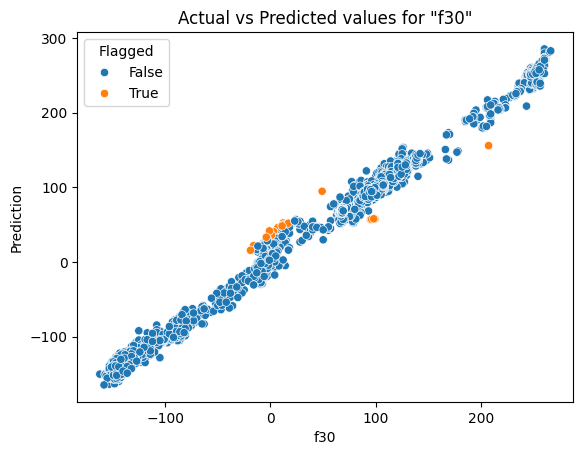

### Columns(s): "f4" AND "f9" AND "f11" AND "f12" AND "f19" AND "f22" AND "f23" AND "f26" AND "f27" AND "f29" AND "f30" AND "f40" AND "f45" AND "f51" AND "f57" AND "f59" AND "f61" AND "f64" AND "f71" AND "f72" AND "f73" AND "f80" AND "f82" AND "f92" AND "f93" AND "f97" AND "f98" AND "f99" AND "f103" AND "f105" AND "f108" AND "f110" AND "f112" AND "f114" AND "f115" AND "f117" AND "f118" AND "f119" AND "f123" AND "f127" AND "f128" AND "f130" AND "f134" AND "f137" AND "f141" AND "f143" AND "f151" AND "f152" AND "f154" AND "f158" AND "f162" AND "f65"

**Issue&nbsp;ID**:&nbsp;3

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;The&nbsp;column&nbsp;"f65"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression<br>formula:&nbsp;&nbsp;0.022&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f4"&nbsp;+&nbsp;&nbsp;0.07&nbsp;*&nbsp;"f9"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f11"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f12"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f19"&nbsp;+<br>0.16&nbsp;*&nbsp;"f22"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"f23"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"f26"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f27"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f29"&nbsp;+&nbsp;&nbsp;0.17&nbsp;*&nbsp;"f30"&nbsp;+&nbsp;&nbsp;0.02<br>*&nbsp;"f40"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f45"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f51"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f57"&nbsp;+&nbsp;&nbsp;0.07&nbsp;*&nbsp;"f59"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f61"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*<br>"f64"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f71"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f72"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f73"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"f80"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f82"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*<br>"f92"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"f93"&nbsp;+&nbsp;&nbsp;0.22&nbsp;*&nbsp;"f97"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"f98"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f99"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f103"&nbsp;+&nbsp;&nbsp;0.16&nbsp;*<br>"f105"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f108"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"f110"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"f112"&nbsp;+&nbsp;&nbsp;0.13&nbsp;*&nbsp;"f114"&nbsp;+&nbsp;&nbsp;0.12&nbsp;*&nbsp;"f115"&nbsp;+&nbsp;&nbsp;0.07<br>*&nbsp;"f117"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f118"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f119"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f123"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f127"&nbsp;+&nbsp;&nbsp;0.27&nbsp;*&nbsp;"f128"&nbsp;+<br>0.39&nbsp;*&nbsp;"f130"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f134"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f137"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"f141"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"f143"&nbsp;+&nbsp;&nbsp;0.12&nbsp;*&nbsp;"f151"&nbsp;+<br>0.74&nbsp;*&nbsp;"f152"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"f154"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"f158"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"f162".&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on<br>scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative<br>importances&nbsp;of&nbsp;the&nbsp;features),&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;4&nbsp;(0.0606%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,f4,f9,f11,f12,f19,f22,f23,f26,f27,f29,...,f137,f141,f143,f151,f152,f154,f158,f162,f65,PREDICTION
1,22,-39,-319,-111,-98,-22,2,-34,45,32,...,53,-26,50,-41,-34,-63,-59,136,-12,-21.002194
11,-71,-19,-317,-254,-197,-21,-31,21,41,-66,...,22,-93,2,-82,-126,-53,-298,142,-134,-133.978510
14,-77,-8,-261,-220,-227,-22,-68,17,-27,25,...,12,-149,18,-82,-122,-44,-88,125,-145,-142.702849
20,-77,-18,-284,-259,-205,-19,-36,24,41,23,...,26,-104,1,-71,-123,-51,-78,35,-146,-145.465543
92,-77,-8,-261,-221,-229,-21,-69,16,-27,24,...,6,-152,20,-108,-122,-18,-89,242,-144,-146.886799
98,24,-40,-317,-111,-100,-22,2,-33,45,30,...,54,-27,49,-54,-34,-148,-54,163,-13,-24.962542
238,18,-44,-316,-116,-103,-26,2,-39,52,25,...,52,-28,46,-37,-37,-70,37,133,-11,-19.040656
251,13,-44,-308,-116,-102,-26,2,-39,52,21,...,52,-28,46,-35,-38,-69,-108,132,-10,-36.570644
582,-7,-31,-48,-25,-18,-16,19,-48,64,14,...,37,-49,66,-7,64,-170,-253,119,97,98.599229
793,-69,-18,-311,-258,-204,-19,-36,24,41,-65,...,26,-104,1,-71,-126,-52,-302,35,-133,-130.225509


**Flagged&nbsp;values**:

,f4,f9,f11,f12,f19,f22,f23,f26,f27,f29,...,f137,f141,f143,f151,f152,f154,f158,f162,f65,PREDICTION
3950,37,-43,-41,-42,5,-18,8,-17,30,-36,...,72,-49,39,244,153,-169,-249,8,18,109.202947
3951,39,-32,-47,-25,-21,-17,18,-49,61,-37,...,35,-51,65,244,151,-170,-247,7,15,99.045436
3954,40,-32,-46,-25,-22,-17,18,-49,61,-3,...,36,-51,66,244,141,-169,-246,-15,-1,52.439151
3955,39,-42,-40,-41,5,-18,7,-17,30,-5,...,72,-49,39,244,145,-168,-248,-15,3,76.974338


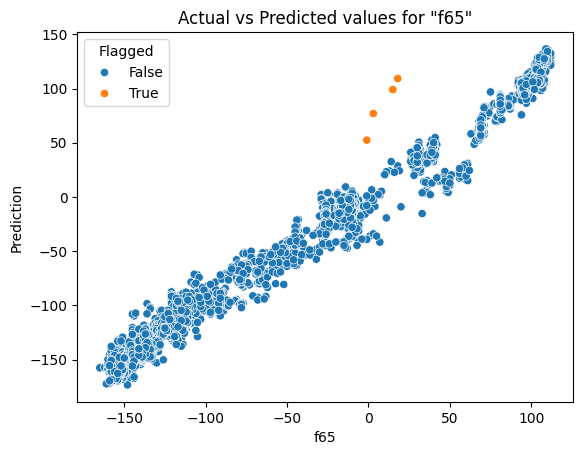

In [27]:
demo_test("musk", test_id_arr=['ALL_POS_OR_ALL_NEG', 'LARGE_GIVEN_PREFIX', 'LINEAR_REGRESSION'], issue_id_arr=[0, 3, 1])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V491,V492,V493,V494,V495,V496,V497,V498,V499,V500
0,485,477,537,479,452,471,491,476,475,473,...,477,481,477,485,511,485,481,479,475,496
1,483,458,460,487,587,475,526,479,485,469,...,463,478,487,338,513,486,483,492,510,517
2,487,542,499,468,448,471,442,478,480,477,...,487,481,492,650,506,501,480,489,499,498
3,480,491,510,485,495,472,417,474,502,476,...,491,480,474,572,454,469,475,482,494,461
4,484,502,528,489,466,481,402,478,487,468,...,488,479,452,435,486,508,481,504,495,511



Data consistency check complete.
Analysed 2,600 rows, 500 columns
Executed 1 tests.

Patterns without Exceptions:
Found 12 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): "V29" AND "V49" AND "V129" AND "V242" AND "V319" AND "V379" AND "V452" AND "V454" AND "V494" AND "V106"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V106"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.011&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"V29"&nbsp;+&nbsp;&nbsp;0.20&nbsp;*&nbsp;"V49"&nbsp;+&nbsp;&nbsp;0.29&nbsp;*&nbsp;"V129"&nbsp;+&nbsp;&nbsp;0.07&nbsp;*&nbsp;"V242"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"V319"&nbsp;+&nbsp;&nbsp;0.18&nbsp;*&nbsp;"V379"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"V452"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"V454"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"V494"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V29,V49,V129,V242,V319,V379,V452,V454,V494,V106,PREDICTION
15,458,421,473,465,415,414,465,701,732,430,426.677430
36,463,539,479,470,440,565,466,548,571,492,497.965503
44,480,496,489,580,484,515,477,376,389,633,623.485204
112,466,520,485,512,443,547,469,513,525,560,569.816791
132,486,448,472,532,504,444,481,318,312,405,398.572982
229,489,422,483,520,518,424,483,459,468,541,536.455856
297,459,471,475,410,411,477,459,807,818,453,462.873317
352,481,501,472,445,490,524,478,527,542,417,408.403766
355,475,513,471,460,468,531,474,414,420,419,397.849784
677,479,504,475,489,482,524,477,489,506,454,449.431251


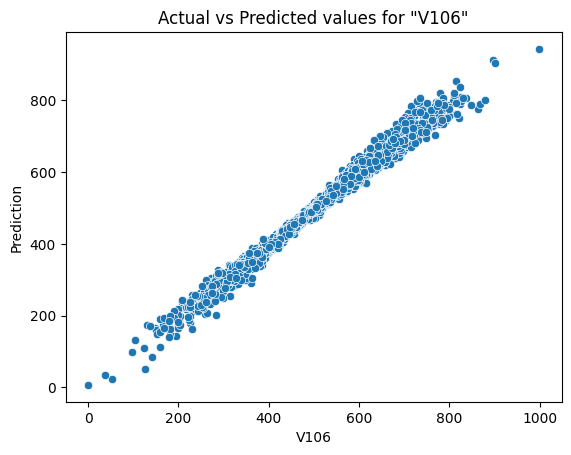

### Columns(s): "V29" AND "V49" AND "V106" AND "V242" AND "V319" AND "V379" AND "V443" AND "V452" AND "V454" AND "V473" AND "V476" AND "V494" AND "V129"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V129"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.010&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"V29"&nbsp;+&nbsp;&nbsp;0.17&nbsp;*&nbsp;"V49"&nbsp;+&nbsp;&nbsp;0.33&nbsp;*&nbsp;"V106"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"V242"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"V319"&nbsp;+&nbsp;&nbsp;0.19&nbsp;*&nbsp;"V379"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.19&nbsp;*&nbsp;"V452"&nbsp;+&nbsp;&nbsp;0.12&nbsp;*&nbsp;"V454"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V473"&nbsp;+&nbsp;&nbsp;0.10&nbsp;*&nbsp;"V476"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"V494"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V29,V49,V106,V242,V319,V379,V443,V452,V454,V473,V476,V494,V129,PREDICTION
1,475,499,431,551,469,526,463,474,311,465,549,338,473,473.372694
4,472,429,451,538,462,424,536,472,426,500,560,435,475,475.023805
6,493,447,571,418,528,444,578,486,657,526,389,648,485,485.005810
11,464,518,519,476,433,539,621,467,578,546,456,599,481,481.367697
12,461,503,469,422,430,517,659,467,661,539,383,696,476,476.307187
13,475,417,498,488,469,410,571,474,616,508,471,649,479,479.016912
16,494,442,408,551,523,432,393,485,235,435,544,207,471,469.903141
21,482,493,511,365,487,506,647,478,620,557,322,708,480,479.176945
31,502,431,489,550,547,425,301,490,381,396,549,357,478,477.845775
52,469,535,667,559,454,595,520,471,473,492,564,487,488,491.528708


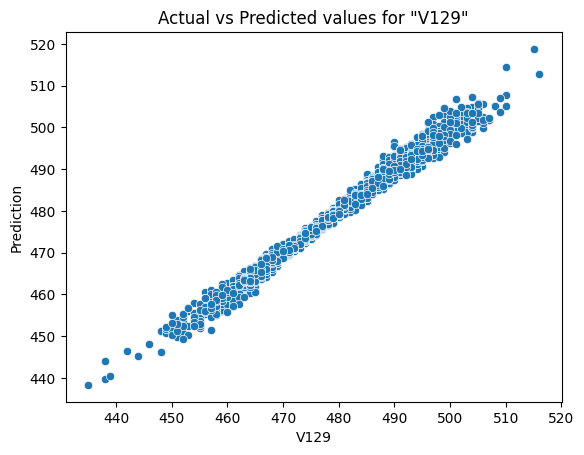

### Columns(s): "V65" AND "V282" AND "V434" AND "V443" AND "V473" AND "V154"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V154"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.004&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"V65"&nbsp;+&nbsp;&nbsp;0.42&nbsp;*&nbsp;"V282"&nbsp;+&nbsp;&nbsp;0.48&nbsp;*&nbsp;"V434"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V473"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V65,V282,V434,V443,V473,V154,PREDICTION
3,415,526,565,447,457,591,583.137873
32,542,427,419,524,499,413,390.756976
45,459,429,423,664,566,422,396.168046
89,542,526,570,622,543,602,584.387616
185,467,519,568,438,456,601,577.291138
189,574,444,449,617,538,434,427.534427
195,524,528,559,602,548,570,579.025295
251,588,519,544,494,479,578,561.117424
261,318,423,412,551,500,408,381.676789
517,545,439,439,626,535,409,413.007149


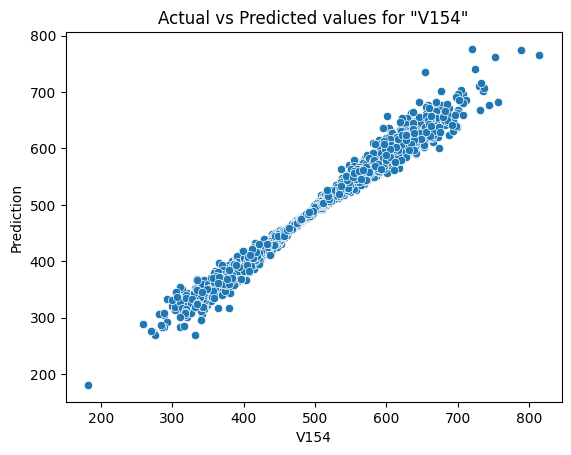

### Columns(s): "V65" AND "V106" AND "V337" AND "V443" AND "V473" AND "V476" AND "V242"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V242"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.010&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V65"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"V106"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V337"&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"V473"&nbsp;+&nbsp;&nbsp;0.90&nbsp;*&nbsp;"V476"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V65,V106,V337,V443,V473,V476,V242,PREDICTION
4,387,451,385,536,500,560,538,554.511421
10,619,380,656,451,462,413,449,446.137890
33,538,464,520,504,484,430,462,459.449021
71,470,559,448,352,406,524,532,527.658878
143,429,650,403,413,445,529,542,531.621031
173,607,392,610,551,502,423,450,453.652698
232,408,608,325,581,521,543,541,542.483389
240,408,677,369,528,498,536,531,537.738780
267,426,720,395,531,500,541,546,541.237938
270,478,566,455,705,555,423,454,455.346797


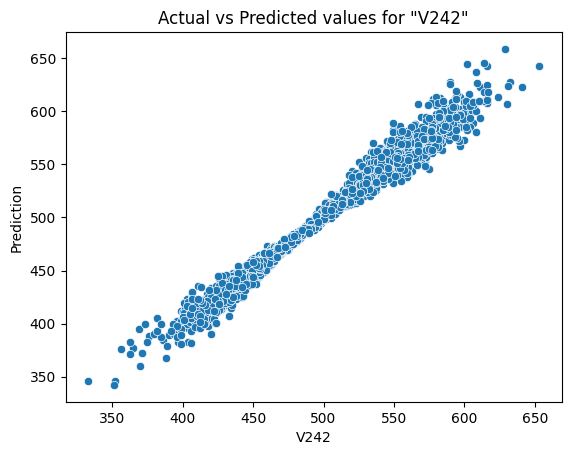

### Columns(s): "V65" AND "V154" AND "V337" AND "V434" AND "V443" AND "V473" AND "V282"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V282"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.002&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"V65"&nbsp;+&nbsp;&nbsp;0.51&nbsp;*&nbsp;"V154"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"V337"&nbsp;+&nbsp;&nbsp;0.38&nbsp;*&nbsp;"V434"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"V473"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V65,V154,V337,V434,V443,V473,V282,PREDICTION
1,488,404,469,442,463,465,435,432.419305
5,348,401,316,435,445,458,429,428.974238
13,438,563,420,541,571,508,519,509.982297
30,623,590,636,573,387,421,523,529.182995
47,548,582,546,558,610,527,516,521.482123
53,462,431,437,454,377,433,441,442.400636
66,570,633,559,582,489,477,537,544.633962
73,574,592,563,564,404,445,532,527.787013
172,421,404,377,434,509,489,428,427.637230
230,572,632,565,592,549,502,533,547.525778


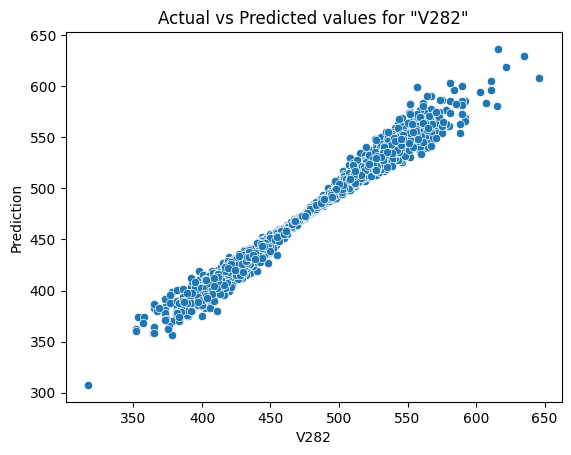

### Columns(s): "V65" AND "V106" AND "V129" AND "V154" AND "V282" AND "V339" AND "V434" AND "V456" AND "V337"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V337"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.006&nbsp;+&nbsp;&nbsp;0.60&nbsp;*&nbsp;"V65"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V106"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"V129"&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"V154"&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"V282"&nbsp;+&nbsp;&nbsp;0.16&nbsp;*&nbsp;"V339"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"V434"&nbsp;+&nbsp;&nbsp;0.36&nbsp;*&nbsp;"V456"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V65,V106,V129,V154,V282,V339,V434,V456,V337,PREDICTION
6,496,571,485,495,476,538,492,389,476,484.110386
68,427,602,487,646,549,327,605,511,415,404.176387
76,543,452,475,591,526,526,555,450,550,540.523886
104,551,430,474,461,456,617,472,459,552,546.802943
139,514,548,483,395,438,504,424,576,506,495.436904
206,461,441,474,430,445,587,455,436,431,436.625250
271,451,756,502,641,553,306,593,453,428,429.725849
301,513,605,487,396,420,590,429,419,492,496.368653
339,563,216,456,412,427,693,437,599,579,577.342356
552,487,338,465,499,478,531,497,548,467,472.312478


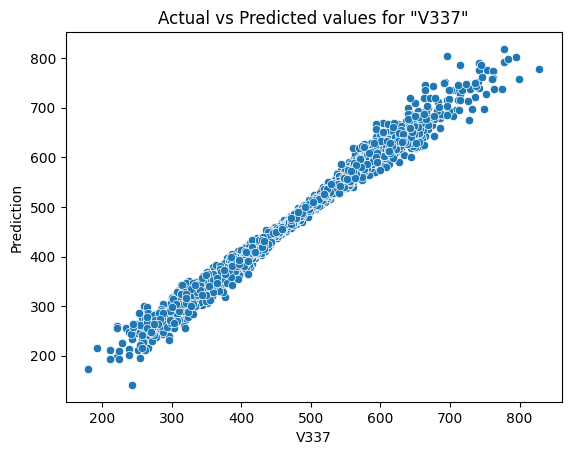

### Columns(s): "V65" AND "V337" AND "V443" AND "V456" AND "V473" AND "V339"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V339"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.012&nbsp;+&nbsp;&nbsp;0.14&nbsp;*&nbsp;"V65"&nbsp;+&nbsp;&nbsp;0.12&nbsp;*&nbsp;"V337"&nbsp;+&nbsp;&nbsp;0.19&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"V456"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"V473"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V65,V337,V443,V456,V473,V339,PREDICTION
15,502,490,611,425,540,484,479.576090
18,646,637,548,533,500,507,508.452804
20,315,287,523,459,487,500,497.344540
40,356,329,457,425,466,453,453.620518
44,320,291,506,432,484,483,476.262050
56,463,443,544,442,509,464,459.114631
119,468,451,401,580,440,506,504.489112
144,539,549,506,473,484,485,487.648711
344,298,296,569,464,521,511,509.936718
561,477,455,394,522,445,442,435.093819


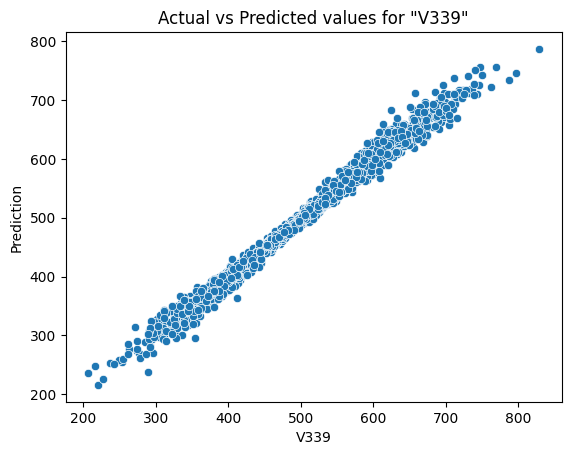

### Columns(s): "V65" AND "V154" AND "V282" AND "V454" AND "V473" AND "V434"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V434"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.001&nbsp;+&nbsp;&nbsp;0.06&nbsp;*&nbsp;"V65"&nbsp;+&nbsp;&nbsp;0.48&nbsp;*&nbsp;"V154"&nbsp;+&nbsp;&nbsp;0.45&nbsp;*&nbsp;"V282"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V454"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"V473"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V65,V154,V282,V454,V473,V434,PREDICTION
1,488,404,435,311,465,442,434.162557
5,348,401,429,428,458,435,428.872935
8,421,598,546,597,453,553,576.583396
29,527,415,434,537,554,441,437.506880
38,547,404,434,591,571,430,434.413399
125,504,571,518,591,518,556,547.716544
129,297,382,429,452,539,422,419.219163
150,530,604,537,709,491,571,574.612673
187,500,601,526,689,526,557,565.765783
656,465,422,433,343,440,440,439.709238


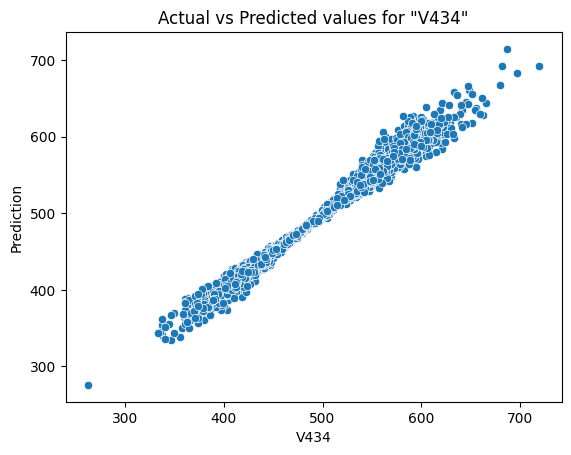

### Columns(s): "V106" AND "V129" AND "V154" AND "V282" AND "V434" AND "V443" AND "V473" AND "V494" AND "V454"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V454"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.047&nbsp;+&nbsp;&nbsp;0.17&nbsp;*&nbsp;"V106"&nbsp;+&nbsp;&nbsp;0.10&nbsp;*&nbsp;"V129"&nbsp;+&nbsp;&nbsp;0.24&nbsp;*&nbsp;"V154"&nbsp;+&nbsp;&nbsp;0.13&nbsp;*&nbsp;"V282"&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"V434"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.10&nbsp;*&nbsp;"V473"&nbsp;+&nbsp;&nbsp;0.29&nbsp;*&nbsp;"V494"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V106,V129,V154,V282,V434,V443,V473,V494,V454,PREDICTION
28,365,467,650,539,589,487,477,561,541,536.962540
56,567,484,562,509,537,544,509,616,590,589.889411
59,624,494,423,433,435,459,463,440,425,422.570993
92,366,467,512,482,503,452,462,417,405,409.226105
206,441,474,430,445,455,650,561,565,540,537.109438
211,277,458,562,513,553,442,454,466,451,450.842294
257,643,492,560,502,531,410,442,542,524,520.415441
326,483,478,546,499,529,574,513,613,582,587.377405
361,418,472,730,603,648,394,434,526,505,511.925066
644,650,489,365,405,408,564,509,545,521,511.622559


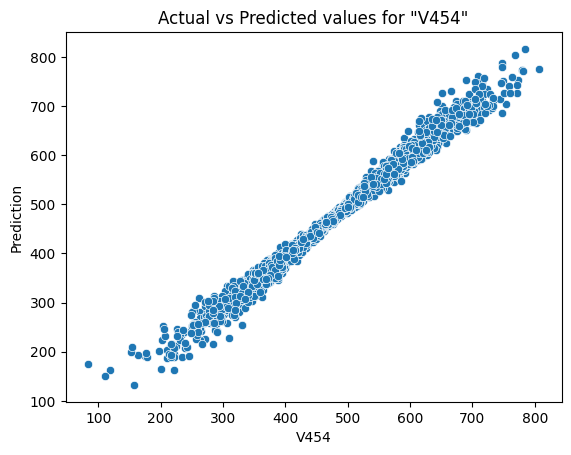

### Columns(s): "V339" AND "V443" AND "V454" AND "V494" AND "V473"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V473"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.044&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"V339"&nbsp;+&nbsp;&nbsp;0.36&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.14&nbsp;*&nbsp;"V454"&nbsp;+&nbsp;&nbsp;0.12&nbsp;*&nbsp;"V494"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V339,V443,V454,V494,V473,PREDICTION
20,500,523,327,285,487,491.042228
33,470,504,589,598,484,485.515225
54,541,478,529,536,472,473.432526
81,428,480,607,665,473,475.025424
101,518,497,536,553,480,481.839751
105,584,468,305,287,468,463.368927
147,539,502,400,395,483,486.565919
153,526,539,604,644,495,500.159474
234,465,462,483,493,467,462.781443
245,505,485,437,449,475,473.832820


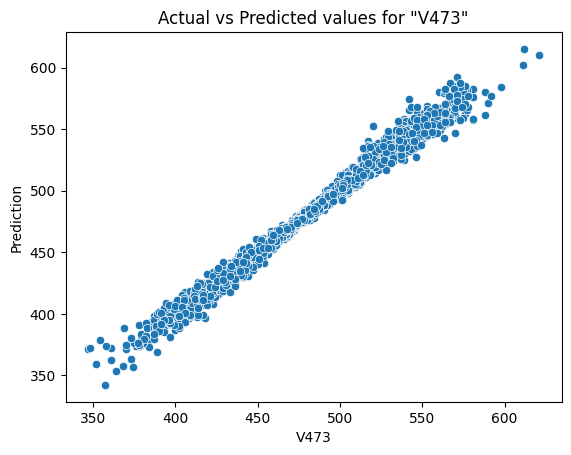

### Columns(s): "V129" AND "V242" AND "V473" AND "V476"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V476"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.000&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"V129"&nbsp;+&nbsp;&nbsp;0.87&nbsp;*&nbsp;"V242"&nbsp;+&nbsp;&nbsp;0.09&nbsp;*&nbsp;"V473"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V129,V242,V473,V476,PREDICTION
5,493,545,458,557,555.866360
10,470,449,462,413,422.596071
33,476,462,484,430,440.740463
38,478,423,571,386,384.685091
47,476,433,527,404,398.339547
110,485,470,450,450,452.084596
170,501,537,473,536,541.886067
208,481,461,524,431,433.472295
340,474,521,468,540,518.974174
434,481,534,500,554,537.730670


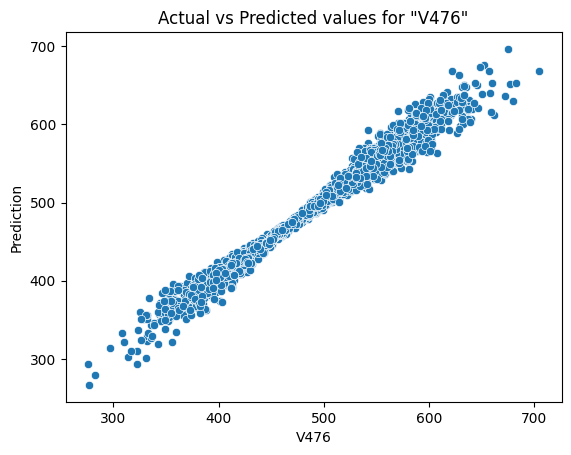

### Columns(s): "V106" AND "V129" AND "V154" AND "V282" AND "V434" AND "V443" AND "V454" AND "V473" AND "V494"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"V494"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.046&nbsp;+&nbsp;&nbsp;0.14&nbsp;*&nbsp;"V106"&nbsp;+&nbsp;&nbsp;0.14&nbsp;*&nbsp;"V129"&nbsp;+&nbsp;&nbsp;0.18&nbsp;*&nbsp;"V154"&nbsp;+&nbsp;&nbsp;0.15&nbsp;*&nbsp;"V282"&nbsp;+&nbsp;&nbsp;0.15&nbsp;*&nbsp;"V434"&nbsp;+&nbsp;&nbsp;0.13&nbsp;*&nbsp;"V443"&nbsp;+&nbsp;&nbsp;0.30&nbsp;*&nbsp;"V454"&nbsp;+&nbsp;&nbsp;0.08&nbsp;*&nbsp;"V473"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,V106,V129,V154,V282,V434,V443,V454,V473,V494,PREDICTION
29,457,475,415,434,441,666,537,554,557,567.157653
30,437,474,590,523,573,387,475,421,489,489.208724
32,523,481,413,427,419,524,466,499,477,479.510663
48,734,497,481,469,485,470,528,469,555,552.209937
60,649,488,628,536,597,404,557,443,574,575.341748
62,628,487,384,402,408,567,536,511,566,554.156185
97,304,462,443,445,454,571,416,516,415,414.800326
161,517,481,620,537,574,267,368,379,384,387.136623
258,637,493,381,410,420,470,431,469,438,437.867972
372,597,485,440,450,455,536,546,497,548,565.341149


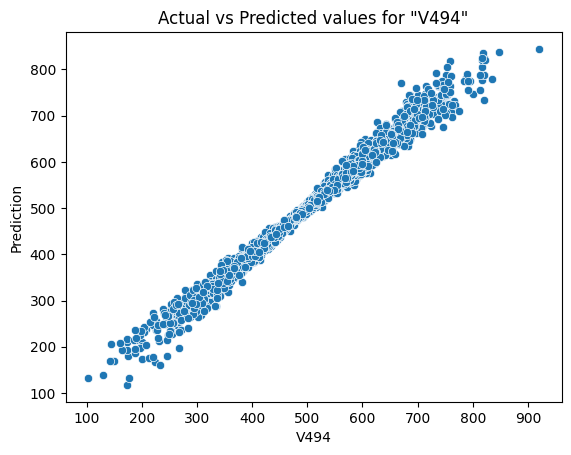

In [28]:
demo_test("madelon", test_id_arr=['LINEAR_REGRESSION'])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118
0,1.0,1.00,1.000000,1.000000,1.000000,1.000000,2,2,0.860946,0.82159,...,0.999967,0.750000,0.500000,2,0.999953,0.777778,0.461538,2,1.0,1.000000
1,1.0,0.75,0.857143,0.857143,0.894737,0.947368,2,1,0.860946,0.82159,...,0.999807,0.500000,0.307692,2,0.999983,0.538462,0.437500,2,1.0,1.000000
2,1.0,1.00,1.000000,1.000000,1.000000,1.000000,2,2,0.860946,0.82159,...,0.999983,0.666667,0.461538,2,0.999993,0.800000,0.666667,2,1.0,1.000000
3,1.0,0.75,0.857143,0.857143,0.842105,0.833333,2,1,1.000000,1.00000,...,0.998023,0.500000,0.285714,2,0.998605,0.555556,0.384615,2,1.0,0.999994
4,0.0,0.00,0.250000,0.000000,0.250000,0.000000,1,1,0.860946,0.82159,...,0.978679,0.607880,0.396168,1,0.982576,0.644336,0.438054,1,1.0,0.979322



Data consistency check complete.
Analysed 34,465 rows, 118 columns
Executed 3 tests.

Patterns without Exceptions:
Found 14 patterns without exceptions
3 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 43 patterns with exceptions
3 tests (100.00% of tests) flagged at least one exception each.
Flagged 1,063 row(s) with at least one exception.
Flagged 29 column(s) with at least one exception.
....................................................................................................


### BINARY_MATCHES_VALUES

### Columns(s): "V6" AND "V8"

**Issue&nbsp;ID**:&nbsp;6

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;57&nbsp;(0.1654%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,V6,V8
0,1.000000,2
2,1.000000,2
3,0.833333,1
4,0.000000,1
5,0.411765,1
6,0.700000,1
13,1.000000,2
15,1.000000,2
16,1.000000,2


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,V6,V8
1,0.947368,1
109,0.947368,1
587,0.947368,1
589,0.947368,1
593,0.947368,1
595,0.947368,1
598,0.947368,1
599,0.947368,1
601,0.947368,1
603,0.947368,1


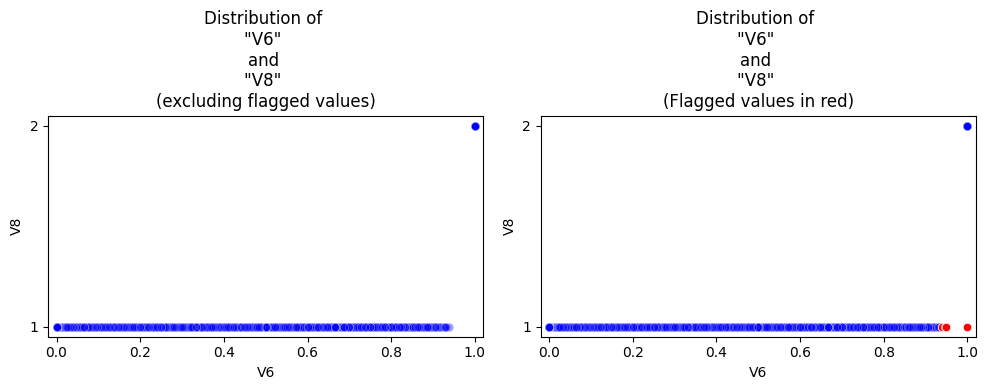

....................................................................................................


### BINARY_MATCHES_SUM

### Columns(s): "V1" AND "V109" AND "V7"

**Issue&nbsp;ID**:&nbsp;10

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;95&nbsp;(0.2756%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,V1,V109,V7,SUM
0,1.000000,0.999967,2,1.999967
1,1.000000,0.999807,2,1.999807
4,0.000000,0.978679,1,0.978679
12,0.500000,0.999194,1,1.499194
14,0.000000,0.997423,1,0.997423
17,0.000000,0.999999,1,0.999999
18,0.000000,0.999935,1,0.999935
7556,0.000000,0.999906,1,0.999906
13856,1.000000,0.978679,2,1.978679
18407,0.500000,0.997279,1,1.497279


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,V1,V109,V7,SUM
474,0.833333,0.999918,1,1.833251
478,0.833333,0.999918,1,1.833251
1210,0.875000,0.999703,1,1.874703
1217,0.875000,0.978679,1,1.853679
2498,0.857143,0.978679,1,1.835822
2502,0.875000,0.997929,1,1.872929
5536,1.000000,0.300583,2,1.300583
5601,1.000000,0.300584,2,1.300584
5662,1.000000,0.298142,2,1.298142
5797,1.000000,0.300579,2,1.300579


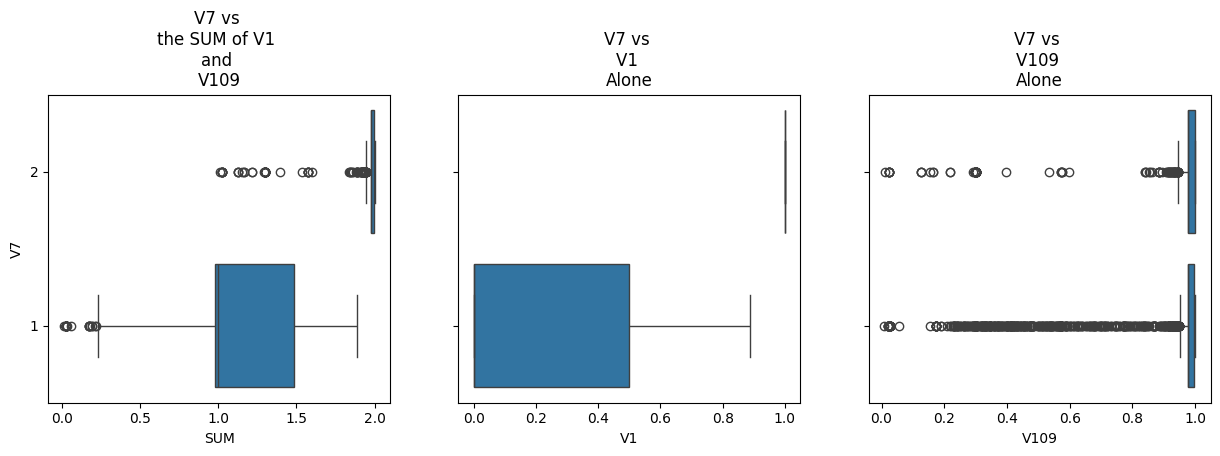

### Columns(s): "V2" AND "V109" AND "V8"

**Issue&nbsp;ID**:&nbsp;20

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;Column&nbsp;"V8"&nbsp;is&nbsp;consistently&nbsp;1&nbsp;when&nbsp;the&nbsp;sum&nbsp;of&nbsp;columns&nbsp;"V2"&nbsp;and&nbsp;"V109"&nbsp;is&nbsp;under&nbsp;1.856603&nbsp;and&nbsp;2&nbsp;when<br>the&nbsp;sum&nbsp;is&nbsp;over,&nbsp;with&nbsp;exceptions.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;47&nbsp;(0.1364%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,V2,V109,V8,SUM
0,1.000000,0.999967,2,1.999967
1,0.750000,0.999807,1,1.749807
2,1.000000,0.999983,2,1.999983
3,0.750000,0.998023,1,1.748023
4,0.000000,0.978679,1,0.978679
5,0.500000,0.999296,1,1.499296
13,1.000000,0.996132,2,1.996132
14,0.000000,0.997423,1,0.997423
15,1.000000,0.978679,2,1.978679
16,1.000000,0.985670,2,1.985670


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,V2,V109,V8,SUM
5797,1.000000,0.300579,2,1.300579
5821,1.000000,0.300579,2,1.300579
5880,1.000000,0.300527,2,1.300527
8591,0.888889,0.978679,1,1.867568
15172,0.857143,1.000000,1,1.857143
15173,0.857143,1.000000,1,1.857143
15176,0.857143,0.999561,1,1.856704
15203,0.857143,0.999999,1,1.857142
15204,0.857143,1.000000,1,1.857143
15207,0.857143,0.999562,1,1.856705


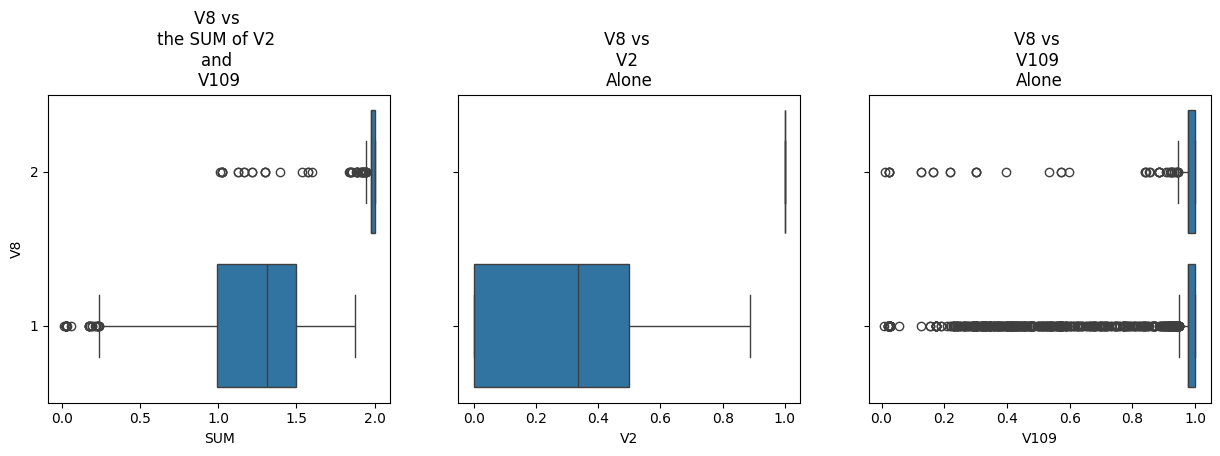

In [29]:
demo_test("nomao", test_id_arr=['BINARY_MATCHES_SUM', 'BINARY_MATCHES_VALUES', 'SIMILAR_WRT_DIFF'], issue_id_arr=[20, 10, 6])

,height,lenght,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans
0,5,7,35,1.400,0.400,0.657,2.33,14,23,6
1,6,7,42,1.167,0.429,0.881,3.60,18,37,5
2,6,18,108,3.000,0.287,0.741,4.43,31,80,7
3,5,7,35,1.400,0.371,0.743,4.33,13,26,3
4,6,3,18,0.500,0.500,0.944,2.25,9,17,4



Data consistency check complete.
Analysed 5,473 rows, 10 columns
Executed 1 tests.

Patterns without Exceptions:
Found 5 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): "lenght" AND "height" AND "eccen"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"eccen"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(within&nbsp;10%)&nbsp;to&nbsp;the&nbsp;ratio&nbsp;of&nbsp;"lenght"&nbsp;and&nbsp;"height"

**Examples**:

,lenght,height,eccen,DIVISION RESULTS
2,18,6,3.000000,3.000000
8,5,5,1.000000,1.000000
19,6,4,1.500000,1.500000
52,12,9,1.333000,1.333333
69,54,9,6.000000,6.000000
157,36,9,4.000000,4.000000
185,14,7,2.000000,2.000000
213,40,8,5.000000,5.000000
782,11,7,1.571000,1.571429
1345,13,7,1.857000,1.857143


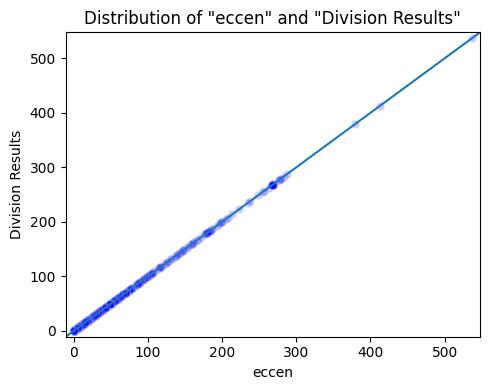

### Columns(s): "area" AND "height" AND "lenght"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"lenght"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(within&nbsp;10%)&nbsp;to&nbsp;the&nbsp;ratio&nbsp;of&nbsp;"area"&nbsp;and&nbsp;"height"

**Examples**:

,area,height,lenght,DIVISION RESULTS
0,35,5,7,7.000000
2,108,6,18,18.000000
5,40,5,8,8.000000
17,95,5,19,19.000000
29,99,11,9,9.000000
36,40,2,20,20.000000
52,108,9,12,12.000000
73,132,12,11,11.000000
77,168,12,14,14.000000
84,13,1,13,13.000000


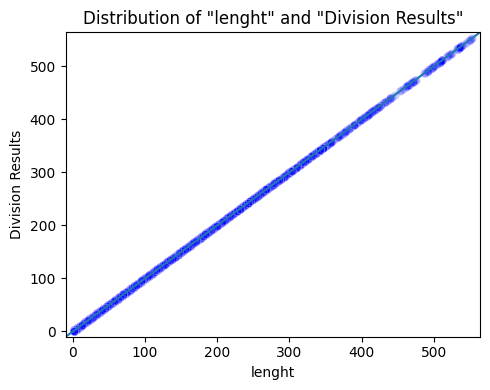

### Columns(s): "blackpix" AND "area" AND "p_black"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"p_black"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(within&nbsp;10%)&nbsp;to&nbsp;the&nbsp;ratio&nbsp;of&nbsp;"blackpix"&nbsp;and&nbsp;"area"

**Examples**:

,blackpix,area,p_black,DIVISION RESULTS
0,14,35,0.400000,0.400000
4,9,18,0.500000,0.500000
7,10,30,0.333000,0.333333
15,15,40,0.375000,0.375000
21,18,72,0.250000,0.250000
22,15,42,0.357000,0.357143
51,237,828,0.286000,0.286232
60,242,828,0.292000,0.292271
83,10,10,1.000000,1.000000
89,39,130,0.300000,0.300000


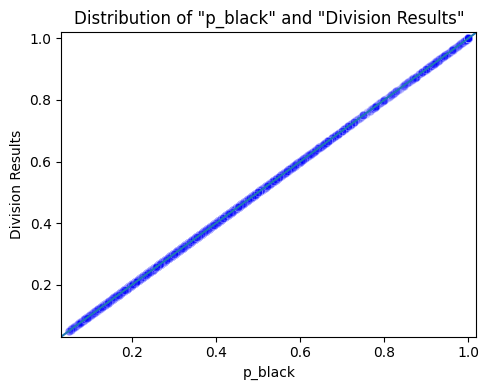

### Columns(s): "blackpix" AND "mean_tr" AND "wb_trans"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"wb_trans"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(within&nbsp;10%)&nbsp;to&nbsp;the&nbsp;ratio&nbsp;of&nbsp;"blackpix"&nbsp;and&nbsp;"mean_tr"

**Examples**:

,blackpix,mean_tr,wb_trans,DIVISION RESULTS
0,14,2.330000,6,6.008584
3,13,4.330000,3,3.002309
5,22,2.440000,9,9.016393
7,10,10.000000,1,1.000000
9,17,8.500000,2,2.000000
27,36,2.570000,14,14.007782
91,37,3.360000,11,11.011905
121,86,10.750000,8,8.000000
137,50,4.170000,12,11.990408
350,25,1.670000,15,14.970060


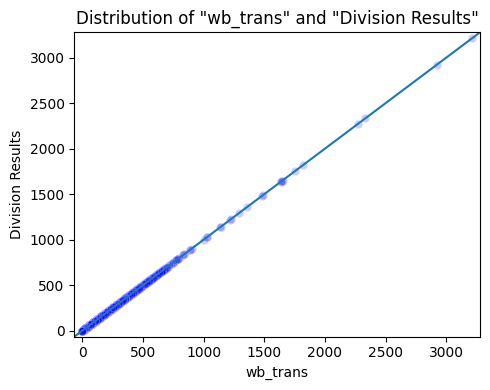

### Columns(s): "blackand" AND "area" AND "p_and"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"p_and"&nbsp;is&nbsp;consistently&nbsp;similar&nbsp;(within&nbsp;10%)&nbsp;to&nbsp;the&nbsp;ratio&nbsp;of&nbsp;"blackand"&nbsp;and&nbsp;"area"

**Examples**:

,blackand,area,p_and,DIVISION RESULTS
5,40,40,1.000000,1.000000
13,30,35,0.857000,0.857143
20,19,24,0.792000,0.791667
24,16,20,0.800000,0.800000
42,431,450,0.958000,0.957778
45,33,44,0.750000,0.750000
49,637,810,0.786000,0.786420
128,1182,1520,0.778000,0.777632
208,210,315,0.667000,0.666667
366,288,324,0.889000,0.888889


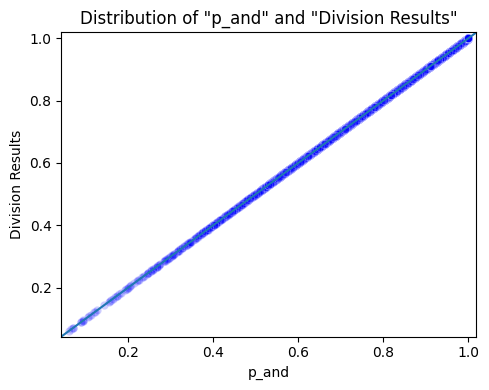

In [30]:
demo_test("page-blocks", test_id_arr=['SIMILAR_TO_RATIO'])

,loc,v(g),ev(g),iv(G),N,V,L,D,I,E,...,T,lOCode,lOComment,locCodeAndComment,lOBlank,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,1.30,2,2,2,2,1.2,1.2,1.2,1.2,1.4
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1,1,1,1,1.0,1.0,1.0,1.0,1.0
2,91.0,9.0,3.0,2.0,318.0,2089.21,0.04,27.68,75.47,57833.24,...,3212.96,80,44,11,31,29.0,66.0,192.0,126.0,17.0
3,109.0,21.0,5.0,18.0,381.0,2547.56,0.04,28.37,89.79,72282.68,...,4015.70,97,41,12,24,28.0,75.0,229.0,152.0,38.0
4,505.0,106.0,41.0,82.0,2339.0,20696.93,0.01,75.93,272.58,1571506.88,...,87305.94,457,71,48,49,64.0,397.0,1397.0,942.0,178.0



Data consistency check complete.
Analysed 1,109 rows, 21 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 2 row(s) with at least one exception.
Flagged 3 column(s) with at least one exception.



### Columns(s): "total_Op" AND "total_Opnd" AND "N"

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.1803%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,total_Op,total_Opnd,N,SUM
29,24.000000,17.000000,41.000000,41.000000
59,6.000000,5.000000,11.000000,11.000000
78,14.000000,11.000000,25.000000,25.000000
87,2.000000,0.000000,2.000000,2.000000
95,18.000000,13.000000,31.000000,31.000000
154,8.000000,4.000000,12.000000,12.000000
171,4.000000,3.000000,7.000000,7.000000
219,15.000000,12.000000,27.000000,27.000000
250,10.000000,7.000000,17.000000,17.000000
480,16.000000,6.000000,22.000000,22.000000


**Flagged&nbsp;values**:

,total_Op,total_Opnd,N,SUM
0,1.200000,1.200000,1.300000,2.400000
1,1.000000,1.000000,1.000000,2.000000


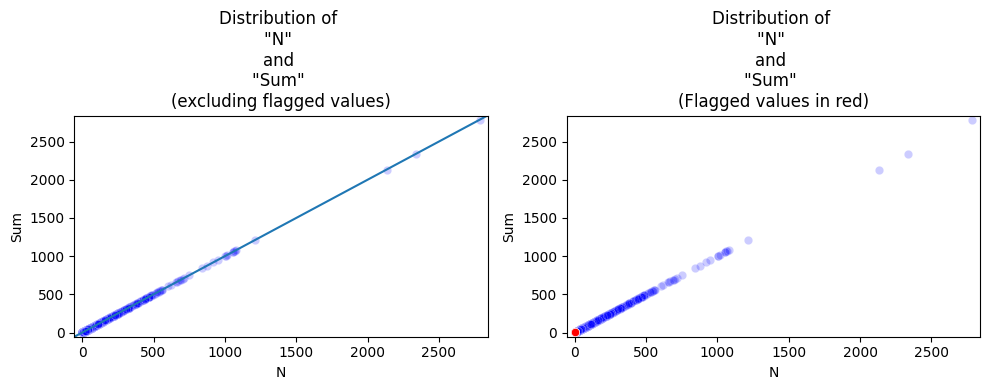

In [31]:
demo_test("pc1", test_id_arr=['SUM_OF_COLUMNS'])

,Favorite_Points,Underdog_Points,Pointspread,Favorite_Name,Underdog_name,Year,Week,Weekday,Overtime
0,27,24,4.0,BUF,MIA,89,1,NaN,NaN
1,17,14,3.0,CHI,CIN,89,1,NaN,NaN
2,51,0,2.5,CLE,PIT,89,1,NaN,NaN
3,28,0,5.5,NO,DAL,89,1,NaN,NaN
4,38,7,5.5,MIN,HOU,89,1,NaN,NaN



Data consistency check complete.
Analysed 672 rows, 9 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 2 row(s) with at least one exception.
Flagged 1 column(s) with at least one exception.



### Columns(s): Week

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

,Week
600,12
601,12
602,12
603,13
604,13
605,13
606,13
607,13
608,13
609,13


**Flagged&nbsp;values**:

,Week
224,1
448,1


Showing&nbsp;a&nbsp;flagged&nbsp;example&nbsp;(row&nbsp;224)&nbsp;with&nbsp;5&nbsp;rows&nbsp;before&nbsp;and&nbsp;5&nbsp;rows&nbsp;after&nbsp;(if&nbsp;available)&nbsp;the&nbsp;flagged&nbsp;row

,Week
219,16
220,16
221,16
222,16
223,16
224,1
225,1
226,1
227,1
228,1


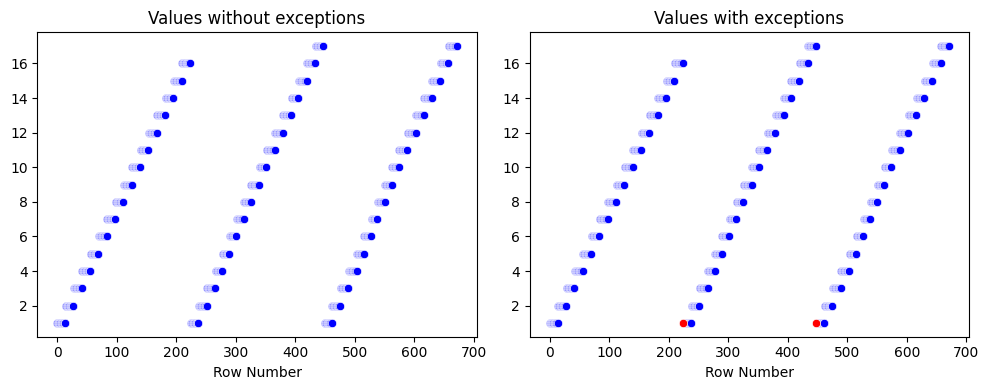

In [32]:
demo_test("profb", test_id_arr=['COLUMN_ORDERED_ASC'])

In [33]:
demo_test("speeddating", test_id_arr=['CHARS_PATTERN'], features_arr=['d_d_age'])

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,2.0,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0



Data consistency check complete.
Analysed 8,378 rows, 120 columns
Executed 1 tests.

Patterns without Exceptions:
Found 54 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;columns:&nbsp;['d_d_age']

### Columns(s): d_d_age

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;Column&nbsp;"d_d_age"&nbsp;consistently&nbsp;contains&nbsp;values&nbsp;with&nbsp;the&nbsp;pattern&nbsp;"[X-X]",&nbsp;where&nbsp;"X"&nbsp;represents&nbsp;alpha-numeric&nbsp;characters

**Examples**:

,d_d_age
0,[4-6]
1,[0-1]
2,[0-1]
3,[2-3]
4,[2-3]
5,[4-6]
6,[7-37]
8,[7-37]
904,[0-1]
4981,[4-6]


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33
0,42,50,270900,270944,267,17,44,24220,76,108,...,1.6435,0.8182,-0.2913,0.5822,1,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,1.4624,0.7931,-0.1756,0.2984,1,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,1.2553,0.6667,-0.1228,0.2150,1,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,1.6532,0.8444,-0.1568,0.5212,1,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,2.4099,0.9338,-0.1992,1.0000,1,0,0,0,0,0



Data consistency check complete.
Analysed 1,941 rows, 33 columns
Executed 1 tests.

Patterns without Exceptions:
Found 1 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): "V3" AND "V4"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;ratio&nbsp;of&nbsp;"V3"&nbsp;and&nbsp;"V4"&nbsp;is&nbsp;consistently&nbsp;close&nbsp;to&nbsp;0.9999758472643326

**Examples**:

,V3,V4,DIVISION RESULTS
1,2538079,2538108,0.999989
2,1553913,1553931,0.999988
3,369370,369415,0.999878
4,498078,498335,0.999484
1775,28972,28984,0.999586
1926,173208,173226,0.999896
1927,252936,252958,0.999913
1928,33298,33323,0.999250
1929,197701,197718,0.999914
1930,244048,244067,0.999922


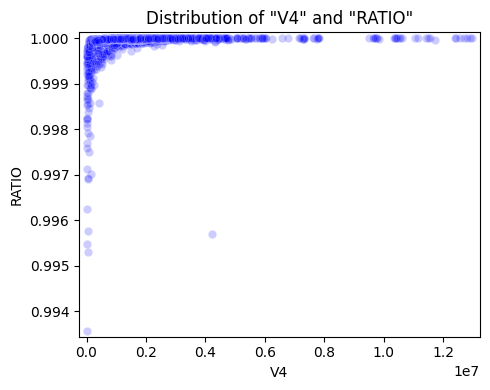

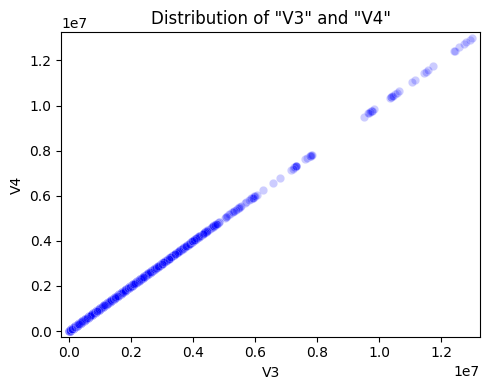

In [34]:
demo_test("steel-plates-fault", test_id_arr=['CONSTANT_RATIO'])

In [35]:
demo_test("segment", test_id_arr=['ALL_POS_OR_ALL_NEG', 'NUMBER_DECIMALS'], issue_id_arr=[0, 1])

,region-centroid-col,region-centroid-row,region-pixel-count,short-line-density-5,short-line-density-2,vedge-mean,vegde-sd,hedge-mean,hedge-sd,intensity-mean,rawred-mean,rawblue-mean,rawgreen-mean,exred-mean,exblue-mean,exgreen-mean,value-mean,saturation-mean,hue-mean
0,218,178,9,0.111111,0.0,0.833333,0.547722,1.111110,0.544331,59.629600,52.4444,75.22220,51.222200,-21.55560,46.7778,-25.22220,75.22220,0.318996,-2.04055
1,113,130,9,0.000000,0.0,0.277778,0.250924,0.333333,0.365148,0.888889,0.0000,2.55556,0.111111,-2.66667,5.0000,-2.33333,2.55556,1.000000,-2.12325
2,202,41,9,0.000000,0.0,0.944448,0.772202,1.111110,1.025600,123.037000,111.8890,139.77800,117.444000,-33.44440,50.2222,-16.77780,139.77800,0.199347,-2.29992
3,32,173,9,0.000000,0.0,1.722220,1.781590,9.000000,6.749490,43.592600,39.5556,52.88890,38.333300,-12.11110,27.8889,-15.77780,52.88890,0.266914,-1.99886
4,61,197,9,0.000000,0.0,1.444440,1.515350,2.611110,1.925460,49.592600,44.2222,61.55560,43.000000,-16.11110,35.8889,-19.77780,61.55560,0.302925,-2.02227


Error ALL_POS_OR_ALL_NEG is not a valid test

Data consistency check complete.
Analysed 2,310 rows, 18 columns
Executed 1 tests.

Patterns without Exceptions:
Found 2 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 1 row(s) with at least one exception.
Flagged 1 column(s) with at least one exception.
....................................................................................................


### NUMBER_DECIMALS

### Columns(s): hue-mean

**Issue&nbsp;ID**:&nbsp;0

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.0433%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,hue-mean,Number decimals
1,-2.12325,5
11,-2.0944,4
58,0.0,0
138,-2.04872,5
187,-2.07124,5
302,-2.13309,5
468,-2.04654,5
480,-2.00619,5
643,-2.01314,5
645,-2.23756,5


**Flagged&nbsp;values**:

,hue-mean,Number decimals
1807,-0.00492694,8


,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,attr10,...,attr290,attr291,attr292,attr293,attr294,Beach,Sunset,FallFoliage,Field,Mountain
0,0.646467,0.666435,0.685047,0.699053,0.652746,0.407864,0.150309,0.535193,0.555689,0.580782,...,0.124074,0.157332,0.247298,0.014025,0.029709,1,0,0,0,1
1,0.770156,0.767255,0.761053,0.745630,0.742231,0.688086,0.708416,0.757351,0.760633,0.740314,...,0.176387,0.251454,0.137833,0.082672,0.036320,1,0,0,0,0
2,0.793984,0.772096,0.761820,0.762213,0.740569,0.734361,0.722677,0.849128,0.839607,0.812746,...,0.006049,0.017166,0.051125,0.112506,0.083924,1,0,0,0,0
3,0.938563,0.949260,0.955621,0.966743,0.968649,0.869619,0.696925,0.953460,0.959631,0.966320,...,0.009735,0.019267,0.031290,0.049780,0.090959,1,0,0,0,0
4,0.512130,0.524684,0.520020,0.504467,0.471209,0.417654,0.364292,0.562266,0.588592,0.584449,...,0.218534,0.198151,0.238796,0.164270,0.184290,1,0,0,0,0



Data consistency check complete.
Analysed 2,407 rows, 299 columns
Executed 1 tests.

Patterns without Exceptions:
Found 5 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 1 row(s) with at least one exception.
Flagged 2 column(s) with at least one exception.



### Columns(s): "Beach" AND "Field"

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.0415%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,Beach,Field
0,1,0
1,1,0
151,1,0
227,0,0
228,0,0
393,0,1
395,0,1
1319,1,0
1929,0,1


**Flagged&nbsp;values**:

,Beach,Field
1376,1,1


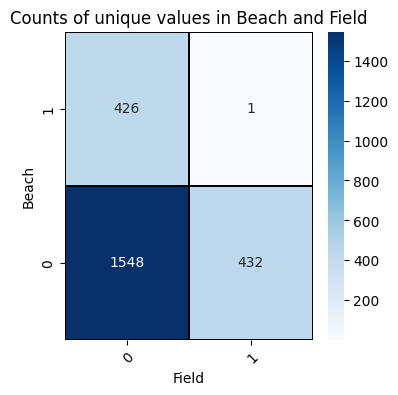

In [36]:
demo_test("scene", test_id_arr=['BINARY_IMPLIES'], issue_id_arr=[0])

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191



Data consistency check complete.
Analysed 4,601 rows, 57 columns
Executed 1 tests.

Patterns without Exceptions:
Found 0 patterns without exceptions
0 tests (0.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 1 patterns with exceptions
1 tests (100.00% of tests) flagged at least one exception each.
Flagged 19 row(s) with at least one exception.
Flagged 2 column(s) with at least one exception.



### Columns(s): "word_freq_857" AND "word_freq_415"

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;19&nbsp;(0.4130%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,word_freq_857,word_freq_415
0,0.000000,0.000000
1833,0.630000,0.630000
1834,0.580000,0.580000
1997,0.760000,0.760000
2010,0.390000,0.390000
2018,0.550000,0.550000
2073,0.680000,0.680000
2283,0.240000,0.240000
2574,4.760000,4.760000


**Examples&nbsp;of&nbsp;flagged&nbsp;values**:

,word_freq_857,word_freq_415
68,0.000000,0.300000
326,0.000000,0.170000
345,0.000000,0.380000
558,0.000000,0.120000
675,0.000000,0.070000
679,0.000000,0.070000
785,0.470000,0.000000
1136,0.000000,0.190000
1185,0.000000,1.350000
1312,0.470000,0.000000


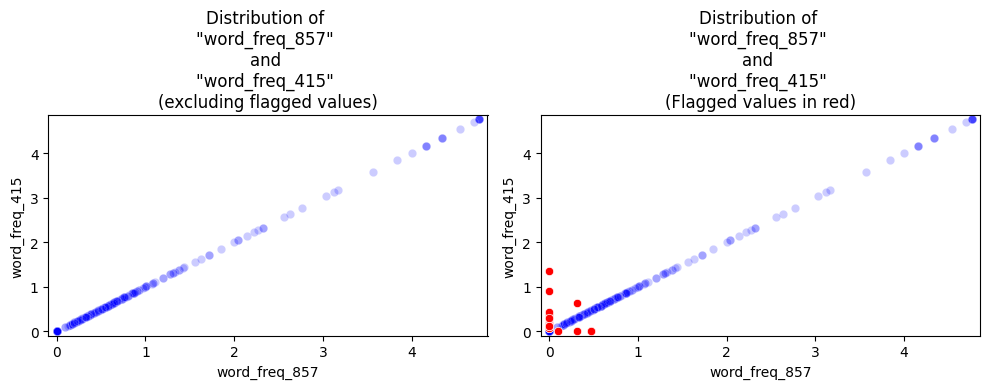

In [37]:
demo_test("Spambase", test_id_arr=['SAME_VALUES'])

In [38]:
demo_test("Soybean", test_id_arr=['MATCHED_MISSING', 'DECISION_TREE_CLASSIFIER'])

,date,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,...,int-discolor,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots
0,october,normal,gt-norm,norm,yes,same-lst-yr,low-areas,pot-severe,none,90-100,...,none,absent,norm,dna,norm,absent,absent,norm,absent,norm
1,august,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,severe,fungicide,80-89,...,none,absent,norm,dna,norm,absent,absent,norm,absent,norm
2,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,fungicide,lt-80,...,none,absent,norm,dna,norm,absent,absent,norm,absent,norm
3,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,none,80-89,...,none,absent,norm,dna,norm,absent,absent,norm,absent,norm
4,october,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,pot-severe,none,lt-80,...,none,absent,norm,dna,norm,absent,absent,norm,absent,norm



Data consistency check complete.
Analysed 683 rows, 35 columns
Executed 2 tests.

Patterns without Exceptions:
Found 7 patterns without exceptions
2 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'MATCHED_MISSING',&nbsp;'DECISION_TREE_CLASSIFIER'

....................................................................................................


### MATCHED_MISSING

...

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:

The values in column "sclerotia" are consistently predictable from ['int-discolor', 'mycelium'] based using a decision tree with the following rules: 
|--- mycelium is not nan
|   |--- int-discolor is not black
|   |   |--- class: absent
|   |--- int-discolor is black
|   |   |--- class: present
|--- mycelium is nan
|   |--- class: nan




**Examples**:

,int-discolor,mycelium,sclerotia,PREDICTION
0,none,absent,absent,absent
1,none,absent,absent,absent
2,none,absent,absent,absent
10,black,absent,present,present
11,black,absent,present,present
12,black,absent,present,present
202,none,absent,absent,absent
296,nan,nan,nan,nan
297,nan,nan,nan,nan
298,nan,nan,nan,nan


,COMPACTNESS,CIRCULARITY,DISTANCE_CIRCULARITY,RADIUS_RATIO,PR.AXIS_ASPECT_RATIO,MAX.LENGTH_ASPECT_RATIO,SCATTER_RATIO,ELONGATEDNESS,PR.AXIS_RECTANGULARITY,MAX.LENGTH_RECTANGULARITY,SCALED_VARIANCE_MAJOR,SCALED_VARIANCE_MINOR,SCALED_RADIUS_OF_GYRATION,SKEWNESS_ABOUT_MAJOR,SKEWNESS_ABOUT_MINOR,KURTOSIS_ABOUT_MAJOR,KURTOSIS_ABOUT_MINOR,HOLLOWS_RATIO
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183



Data consistency check complete.
Analysed 846 rows, 18 columns
Executed 2 tests.

Patterns without Exceptions:
Found 4 patterns without exceptions
2 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



Displaying&nbsp;results&nbsp;for&nbsp;tests:&nbsp;'LINEAR_REGRESSION',&nbsp;'SIMILAR_WRT_DIFF'

....................................................................................................


### LINEAR_REGRESSION

### Columns(s): "DISTANCE_CIRCULARITY" AND "PR.AXIS_RECTANGULARITY" AND "MAX.LENGTH_RECTANGULARITY" AND "SCALED_VARIANCE_MAJOR" AND "SCALED_VARIANCE_MINOR" AND "KURTOSIS_ABOUT_MAJOR" AND "SCATTER_RATIO"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"SCATTER_RATIO"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.008&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"DISTANCE_CIRCULARITY"&nbsp;+&nbsp;&nbsp;0.12&nbsp;*&nbsp;"PR.AXIS_RECTANGULARITY"&nbsp;+&nbsp;&nbsp;0.04&nbsp;*&nbsp;"MAX.LENGTH_RECTANGULARITY"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"SCALED_VARIANCE_MAJOR"&nbsp;+&nbsp;&nbsp;0.62&nbsp;*&nbsp;"SCALED_VARIANCE_MINOR"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"KURTOSIS_ABOUT_MAJOR"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,DISTANCE_CIRCULARITY,PR.AXIS_RECTANGULARITY,MAX.LENGTH_RECTANGULARITY,SCALED_VARIANCE_MAJOR,SCALED_VARIANCE_MINOR,KURTOSIS_ABOUT_MAJOR,SCATTER_RATIO,PREDICTION
1,84,19,143,170,330,14,149,149.776718
6,73,19,143,176,361,1,153,154.265624
12,74,19,148,180,349,11,152,153.117192
20,75,19,145,175,354,3,154,153.651325
22,64,19,142,169,344,1,150,150.694412
25,80,19,148,169,324,4,147,148.564130
30,85,19,151,173,356,9,155,155.056384
35,90,20,150,170,363,7,157,156.329723
39,68,19,146,173,336,0,151,149.973950
47,66,19,141,172,317,14,148,146.812827


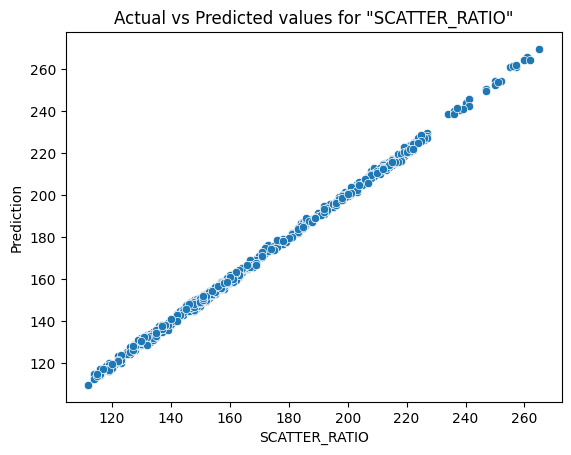

### Columns(s): "DISTANCE_CIRCULARITY" AND "PR.AXIS_RECTANGULARITY" AND "MAX.LENGTH_RECTANGULARITY" AND "SCALED_VARIANCE_MINOR" AND "ELONGATEDNESS"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"ELONGATEDNESS"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>-0.014&nbsp;+&nbsp;&nbsp;0.11&nbsp;*&nbsp;"DISTANCE_CIRCULARITY"&nbsp;+&nbsp;&nbsp;0.25&nbsp;*&nbsp;"PR.AXIS_RECTANGULARITY"&nbsp;+&nbsp;&nbsp;0.16&nbsp;*&nbsp;"MAX.LENGTH_RECTANGULARITY"&nbsp;+&nbsp;&nbsp;1.52&nbsp;*&nbsp;"SCALED_VARIANCE_MINOR"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,DISTANCE_CIRCULARITY,PR.AXIS_RECTANGULARITY,MAX.LENGTH_RECTANGULARITY,SCALED_VARIANCE_MINOR,ELONGATEDNESS,PREDICTION
0,83,20,159,379,42,41.172859
1,84,19,143,330,45,45.574047
2,106,23,158,635,32,31.297660
3,82,19,143,309,46,46.895957
12,74,19,148,349,43,43.820818
13,85,19,144,345,44,44.714958
18,100,24,173,686,31,30.500494
28,85,22,146,570,33,35.504608
64,86,22,145,523,35,37.040073
67,101,25,178,748,30,29.796393


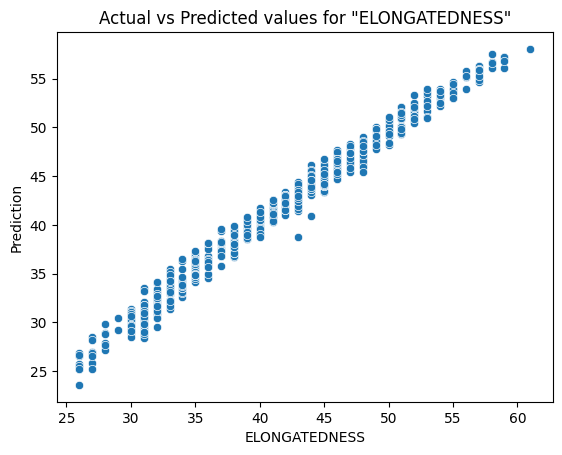

### Columns(s): "COMPACTNESS" AND "CIRCULARITY" AND "RADIUS_RATIO" AND "SCATTER_RATIO" AND "ELONGATEDNESS" AND "PR.AXIS_RECTANGULARITY" AND "SCALED_VARIANCE_MAJOR" AND "SCALED_VARIANCE_MINOR"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;column&nbsp;"SCALED_VARIANCE_MINOR"&nbsp;contains&nbsp;values&nbsp;that&nbsp;are&nbsp;consistently&nbsp;predictable&nbsp;based&nbsp;on&nbsp;a&nbsp;linear&nbsp;regression&nbsp;formula:&nbsp;<br>0.039&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"COMPACTNESS"&nbsp;+&nbsp;&nbsp;0.05&nbsp;*&nbsp;"CIRCULARITY"&nbsp;+&nbsp;&nbsp;0.02&nbsp;*&nbsp;"RADIUS_RATIO"&nbsp;+&nbsp;&nbsp;1.23&nbsp;*&nbsp;"SCATTER_RATIO"&nbsp;+&nbsp;&nbsp;0.28&nbsp;*&nbsp;"ELONGATEDNESS"&nbsp;+&nbsp;&nbsp;0.03&nbsp;*&nbsp;"PR.AXIS_RECTANGULARITY"&nbsp;+&nbsp;&nbsp;0.01&nbsp;*&nbsp;"SCALED_VARIANCE_MAJOR"&nbsp;.&nbsp;(The&nbsp;co-efficients&nbsp;are&nbsp;based&nbsp;on&nbsp;scaled&nbsp;values&nbsp;and&nbsp;do&nbsp;not&nbsp;apply&nbsp;the&nbsp;the&nbsp;original&nbsp;values.&nbsp;This&nbsp;is&nbsp;to&nbsp;represent&nbsp;the&nbsp;relative&nbsp;importances&nbsp;of&nbsp;the&nbsp;features)

**Examples**:

,COMPACTNESS,CIRCULARITY,RADIUS_RATIO,SCATTER_RATIO,ELONGATEDNESS,PR.AXIS_RECTANGULARITY,SCALED_VARIANCE_MAJOR,SCALED_VARIANCE_MINOR,PREDICTION
1,91,41,141,149,45,19,170,330,323.075325
4,85,44,205,149,45,19,241,325,340.845389
20,84,47,153,154,43,19,175,354,355.240333
53,101,42,175,149,43,19,169,341,336.097986
63,83,42,156,150,45,19,174,333,338.028032
107,85,39,151,150,45,19,176,331,336.215941
147,91,40,171,149,44,19,169,332,329.634028
189,90,36,179,157,42,19,182,367,372.186147
270,82,45,150,148,45,19,169,322,326.877926
276,83,46,137,148,45,19,167,327,323.586267


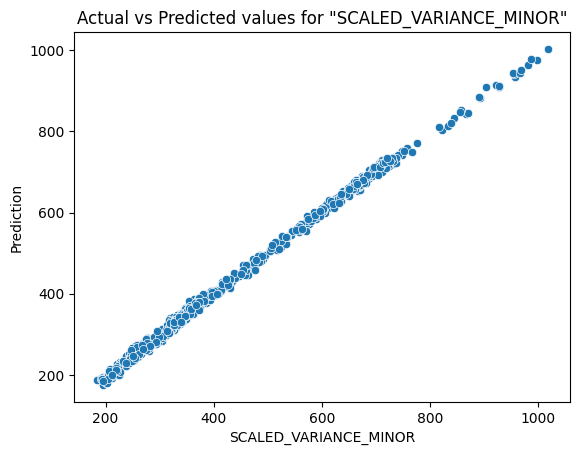

....................................................................................................


### SIMILAR_WRT_DIFF

### Columns(s): "KURTOSIS_ABOUT_MINOR" AND "HOLLOWS_RATIO"

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;"KURTOSIS_ABOUT_MINOR"&nbsp;and&nbsp;"HOLLOWS_RATIO"&nbsp;have&nbsp;consistently&nbsp;similar&nbsp;values&nbsp;in&nbsp;terms&nbsp;of&nbsp;their&nbsp;absolute&nbsp;difference&nbsp;(with&nbsp;33&nbsp;rows&nbsp;having&nbsp;identical&nbsp;values).&nbsp;Rows&nbsp;with&nbsp;values&nbsp;of&nbsp;zero&nbsp;are&nbsp;not&nbsp;tested.

**Examples**:

,KURTOSIS_ABOUT_MINOR,HOLLOWS_RATIO,DIFF
0,187,197,-10.000000
1,189,199,-10.000000
2,188,196,-8.000000
4,180,183,-3.000000
7,193,202,-9.000000
12,189,195,-6.000000
24,191,201,-10.000000
35,192,200,-8.000000
54,180,184,-4.000000
71,186,198,-12.000000


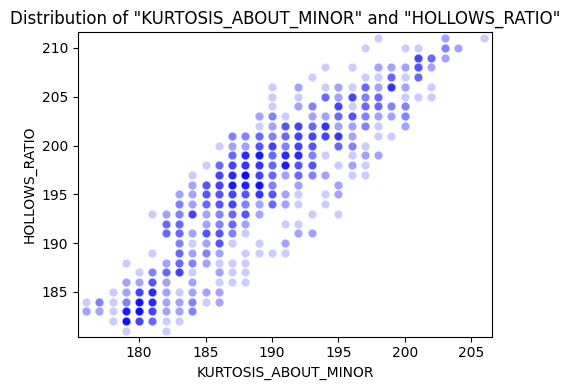

In [39]:
demo_test("Vehicle", test_id_arr=['LINEAR_REGRESSION', 'SIMILAR_WRT_DIFF'])

In [40]:
demo_test("vowel", test_id_arr=['GROUPED_STRINGS'])

,Train_or_Test,Speaker_Number,Sex,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9
0,Train,Andrew,Male,-3.639,0.418,-0.670,1.779,-0.168,1.627,-0.388,0.529,-0.874,-0.814
1,Train,Andrew,Male,-3.327,0.496,-0.694,1.365,-0.265,1.933,-0.363,0.510,-0.621,-0.488
2,Train,Andrew,Male,-2.120,0.894,-1.576,0.147,-0.707,1.559,-0.579,0.676,-0.809,-0.049
3,Train,Andrew,Male,-2.287,1.809,-1.498,1.012,-1.053,1.060,-0.567,0.235,-0.091,-0.795
4,Train,Andrew,Male,-2.598,1.938,-0.846,1.062,-1.633,0.764,0.394,-0.150,0.277,-0.396



Data consistency check complete.
Analysed 990 rows, 13 columns
Executed 1 tests.

Patterns without Exceptions:
Found 1 patterns without exceptions
1 tests (100.00% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 0 patterns with exceptions
0 tests (0.00% of tests) flagged at least one exception each.
Flagged 0 row(s) with at least one exception.
Flagged 0 column(s) with at least one exception.



### Columns(s): Speaker_Number

Pattern&nbsp;found&nbsp;(without&nbsp;exceptions)

**Description**:&nbsp;The&nbsp;values&nbsp;in&nbsp;"Speaker_Number"&nbsp;are&nbsp;consistently&nbsp;grouped&nbsp;together.&nbsp;The&nbsp;overall&nbsp;order&nbsp;is:&nbsp;<br>Value:&nbsp;"Andrew":&nbsp;rows&nbsp;0&nbsp;to&nbsp;65<br>Value:&nbsp;"Bill":&nbsp;rows&nbsp;66&nbsp;to&nbsp;131<br>Value:&nbsp;"David":&nbsp;rows&nbsp;132&nbsp;to&nbsp;197<br>Value:&nbsp;"Mark":&nbsp;rows&nbsp;198&nbsp;to&nbsp;263<br>Value:&nbsp;"Jo":&nbsp;rows&nbsp;264&nbsp;to&nbsp;329<br>Value:&nbsp;"Kate":&nbsp;rows&nbsp;330&nbsp;to&nbsp;395<br>Value:&nbsp;"Penny":&nbsp;rows&nbsp;396&nbsp;to&nbsp;461<br>Value:&nbsp;"Rose":&nbsp;rows&nbsp;462&nbsp;to&nbsp;527<br>Value:&nbsp;"Mike":&nbsp;rows&nbsp;528&nbsp;to&nbsp;593<br>Value:&nbsp;"Nick":&nbsp;rows&nbsp;594&nbsp;to&nbsp;659<br>Value:&nbsp;"Rich":&nbsp;rows&nbsp;660&nbsp;to&nbsp;725<br>Value:&nbsp;"Tim":&nbsp;rows&nbsp;726&nbsp;to&nbsp;791<br>Value:&nbsp;"Sarah":&nbsp;rows&nbsp;792&nbsp;to&nbsp;857<br>Value:&nbsp;"Sue":&nbsp;rows&nbsp;858&nbsp;to&nbsp;923<br>Value:&nbsp;"Wendy":&nbsp;rows&nbsp;924&nbsp;to&nbsp;989.

Examples&nbsp;are&nbsp;not&nbsp;shown&nbsp;for&nbsp;this&nbsp;pattern.